#  Friction Stir Welding (FSW) — Comprehensive Data Analysis & Machine Learning

**Dataset:** Literature survey of FSW research papers (~1680 experiments across journals 2003–2026)

## Table of Contents
1. [Setup & Data Loading](#1)
2. [Data Cleaning & Preprocessing](#2)
3. [Exploratory Data Analysis (EDA)](#3)
   - 3.1 Publication trends
   - 3.2 Materials analysis
   - 3.3 Process parameter distributions
   - 3.4 Mechanical properties
4. [Statistical Analysis](#4)
   - 4.1 Correlation analysis
   - 4.2 ANOVA tests
   - 4.3 Effect of joint type
5. [Machine Learning — Regression: Predicting UTS](#5)
   - 5.1 Feature engineering
   - 5.2 Linear Regression
   - 5.3 Random Forest
   - 5.4 XGBoost
   - 5.5 Model comparison
6. [Machine Learning — Hardness Prediction](#6)
7. [Feature Importance & SHAP Analysis](#7)
8. [Clustering — Material & Process Groupings](#8)
9. [ML — Classification: Joint Type Prediction](#9)
10. [Parameter Optimization Insights](#10)
11. [Research Gaps & Recommendations](#11)

---
## 1. Setup & Data Loading <a id='1'></a>

In [1]:
# ── Core libraries ──────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import f_oneway, kruskal
import statsmodels.api as sm

# ── ML libraries ────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, RandomForestClassifier
from sklearn.svm import SVR, SVC
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import (mean_squared_error, r2_score, mean_absolute_error,
                             accuracy_score, classification_report, confusion_matrix)
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import xgboost as xgb
import shap

# ── Plot style ───────────────────────────────────────────────────────────────
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_theme(style='whitegrid', palette='muted')
COLORS = sns.color_palette('Set2', 12)

print('All libraries loaded successfully ✅')

All libraries loaded successfully ✅


In [2]:
# ── Load raw CSV ─────────────────────────────────────────────────────────────
RAW = pd.read_csv('data_fsw.csv', header=0)
print(f'Raw shape: {RAW.shape}')

# Rows 0 and 1 are sub-header rows (column label continuation)
# Actual data starts at row index 2
df_raw = RAW.iloc[2:].copy().reset_index(drop=True)
print(f'Data rows (after removing header rows): {len(df_raw)}')
df_raw.head(3)

Raw shape: (1682, 44)
Data rows (after removing header rows): 1680


,DOI,Journal,Year,Author,Joint,Materials AS,Material RS,Tool materials,Filler Metal,Shoulder feature,...,Unnamed: 34,Unnamed: 35,Unnamed: 36,Unnamed: 37,Unnamed: 38,Unnamed: 39,Unnamed: 40,Unnamed: 41,Unnamed: 42,Unnamed: 43
0,https://doi.org/10.1016/j.matchar.2005.12.015,Materials Characterization,2006.0,P.Cavaliere,Butt,AA2014,NaN,NaN,NaN,cylindrical,...,NaN,NaN,NaN,NaN,NaN,440,650,NaN,NaN,NaN
1,https://doi.org/10.1016/j.msea.2009.07.006,Materials Science and Engineering: A,2009.0,Ulrike Dressler,Butt,Ti6Al4V,AA2024-T3,Tool steel,NaN,Concave,...,NaN,NaN,NaN,NaN,325-135-150,NaN,"348 (W), 476 (B-AA2024)",NaN,NaN,"0.5 (W), 25.7 (B-AA2024)"
2,NaN,Materials Science and Engineering: A,2009.0,Ulrike Dressler,Butt,Ti6Al4V,AA2024-T3,Tool steel,NaN,Concave,...,NaN,NaN,NaN,NaN,325-135-150,NaN,"348 (W), 476 (B-AA2024)",NaN,NaN,"0.5 (W), 25.7 (B-AA2024)"


---
## 2. Data Cleaning & Preprocessing <a id='2'></a>

In [3]:
# ── Rename columns to clean names ────────────────────────────────────────────
df = df_raw.copy()

rename_map = {
    'DOI': 'DOI',
    'Journal': 'Journal',
    'Year': 'Year',
    'Author': 'Author',
    'Joint': 'Joint_Type',
    'Materials AS': 'Material_AS',      # Advancing Side
    'Material RS': 'Material_RS',       # Retreating Side
    'Tool materials': 'Tool_Material',
    'Filler Metal': 'Filler_Metal',
    'Shoulder feature': 'Shoulder_Feature',
    'Shoulder Dia. (mm)': 'Shoulder_Dia_mm',
    'Probe Length (mm)': 'Probe_Length_mm',
    'Probe Features': 'Probe_Feature',
    'Probe Dia. Root (mm)': 'Probe_Dia_Root_mm',
    'Probe Dia. Tip (mm)': 'Probe_Dia_Tip_mm',
    'Scribe Dia (mm)': 'Scribe_Dia_mm',
    'Scribe Length (mm)': 'Scribe_Length_mm',
    'Treatment': 'Treatment',
    'Temperature            (° C)': 'Temperature_C',
    'Tool Torque (N-m)': 'Torque_Nm',
    'Axial Load              (  KN) ': 'Axial_Load_KN',
    'Tool Rotation (RPM)': 'Rotation_RPM',
    'Tool travers (mm/min)': 'Traverse_mmpm',
    'Tool Offset (mm)': 'Tool_Offset_mm',
    'Plunge Depth (mm)': 'Plunge_Depth_mm',
    'Tool Tilt (Deg.)': 'Tilt_Deg',
    'Cooling Media': 'Cooling_Media',
    'Metallurgical Charecterisation ': 'Metall_Char',
    'Unnamed: 28': 'SEM',
    'Unnamed: 29': 'TEM',
    'Unnamed: 30': 'XRD',
    'Mechanical charecterisation': 'Mech_Char',
    'Unnamed: 32': 'Fracture_Strain_pct',
    'Unnamed: 33': 'Weld_Efficiency_pct',
    'Unnamed: 34': 'Corrosion_Resist',
    'Unnamed: 35': 'Toughness',
    'Unnamed: 36': 'Shear_Fail_Load_KN',
    'Unnamed: 37': 'Impact_Strength_J',
    'Unnamed: 38': 'Hardness_HV',
    'Unnamed: 39': 'YS_MPa',
    'Unnamed: 40': 'UTS_MPa',
    'Unnamed: 41': 'Youngs_Mod_GPa',
    'Unnamed: 42': 'Residual_Stress_MPa',
    'Unnamed: 43': 'Strain_pct',
    'Maximum\nbending moment\n(Nm)': 'Max_Bending_Nm',
}
df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns}, inplace=True)

# ── Convert numeric columns ──────────────────────────────────────────────────
numeric_cols = [
    'Year', 'Shoulder_Dia_mm', 'Probe_Length_mm', 'Probe_Dia_Root_mm',
    'Probe_Dia_Tip_mm', 'Scribe_Dia_mm', 'Scribe_Length_mm',
    'Temperature_C', 'Torque_Nm', 'Axial_Load_KN', 'Rotation_RPM',
    'Traverse_mmpm', 'Plunge_Depth_mm',
    'Weld_Efficiency_pct', 'Hardness_HV', 'YS_MPa', 'UTS_MPa',
    'Strain_pct', 'Impact_Strength_J', 'Toughness'
]
for c in numeric_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')

# ── Clean categorical columns ────────────────────────────────────────────────
cat_clean = ['Joint_Type', 'Material_AS', 'Material_RS', 'Tool_Material',
             'Shoulder_Feature', 'Probe_Feature']
for c in cat_clean:
    if c in df.columns:
        df[c] = df[c].astype(str).str.strip().replace({'nan': np.nan, 'NaN': np.nan})

# Normalise Joint_Type (T vs 'T ')
df['Joint_Type'] = df['Joint_Type'].str.strip()

print(f'Clean dataset shape: {df.shape}')
print('\nMissing values per key column:')
key_cols = ['Joint_Type','Material_AS','Material_RS','Tool_Material',
            'Rotation_RPM','Traverse_mmpm','Shoulder_Dia_mm','Probe_Length_mm',
            'UTS_MPa','Hardness_HV','YS_MPa','Strain_pct','Weld_Efficiency_pct']
miss = df[key_cols].isnull().sum()
miss_pct = (miss / len(df) * 100).round(1)
pd.DataFrame({'Missing': miss, 'Missing_%': miss_pct})

Clean dataset shape: (1680, 44)

Missing values per key column:


,Missing,Missing_%
Joint_Type,900,53.6
Material_AS,9,0.5
Material_RS,23,1.4
Tool_Material,991,59.0
Rotation_RPM,141,8.4
Traverse_mmpm,103,6.1
Shoulder_Dia_mm,422,25.1
Probe_Length_mm,687,40.9
UTS_MPa,1569,93.4
Hardness_HV,1614,96.1


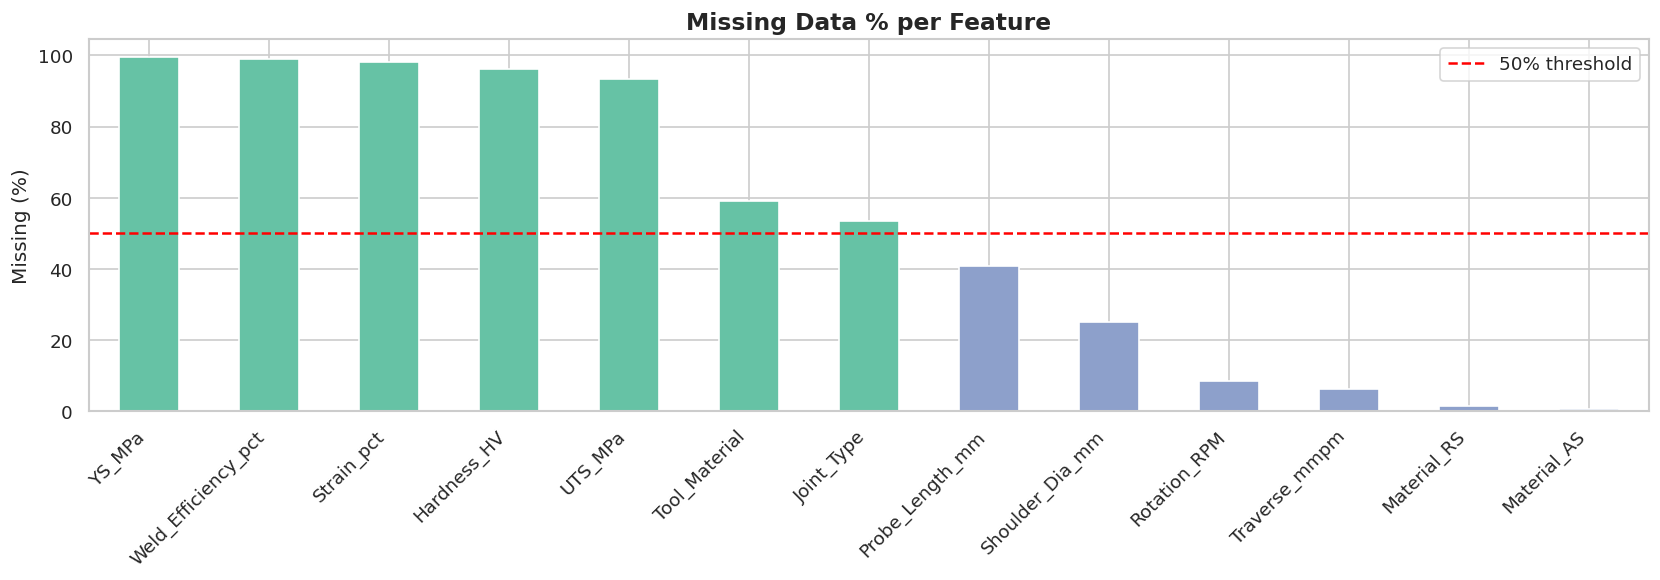


⚠️  Columns with >50% missing are less suitable as ML targets alone; use them alongside other evidence.


In [4]:
# ── Missing-value heatmap ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
key_for_miss = [c for c in key_cols if c in df.columns]
miss_data = df[key_for_miss].isnull()

miss_pct_plot = miss_data.mean().sort_values(ascending=False) * 100
miss_pct_plot.plot(kind='bar', ax=ax, color=[COLORS[0] if v > 50 else COLORS[2] for v in miss_pct_plot])
ax.set_title('Missing Data % per Feature', fontsize=14, fontweight='bold')
ax.set_ylabel('Missing (%)')
ax.set_xlabel('')
ax.axhline(50, color='red', linestyle='--', label='50% threshold')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('fig_missing_data.png', bbox_inches='tight')
plt.show()
print('\n⚠️  Columns with >50% missing are less suitable as ML targets alone; use them alongside other evidence.')

---
## 3. Exploratory Data Analysis (EDA) <a id='3'></a>
### 3.1 Publication Trends Over Time

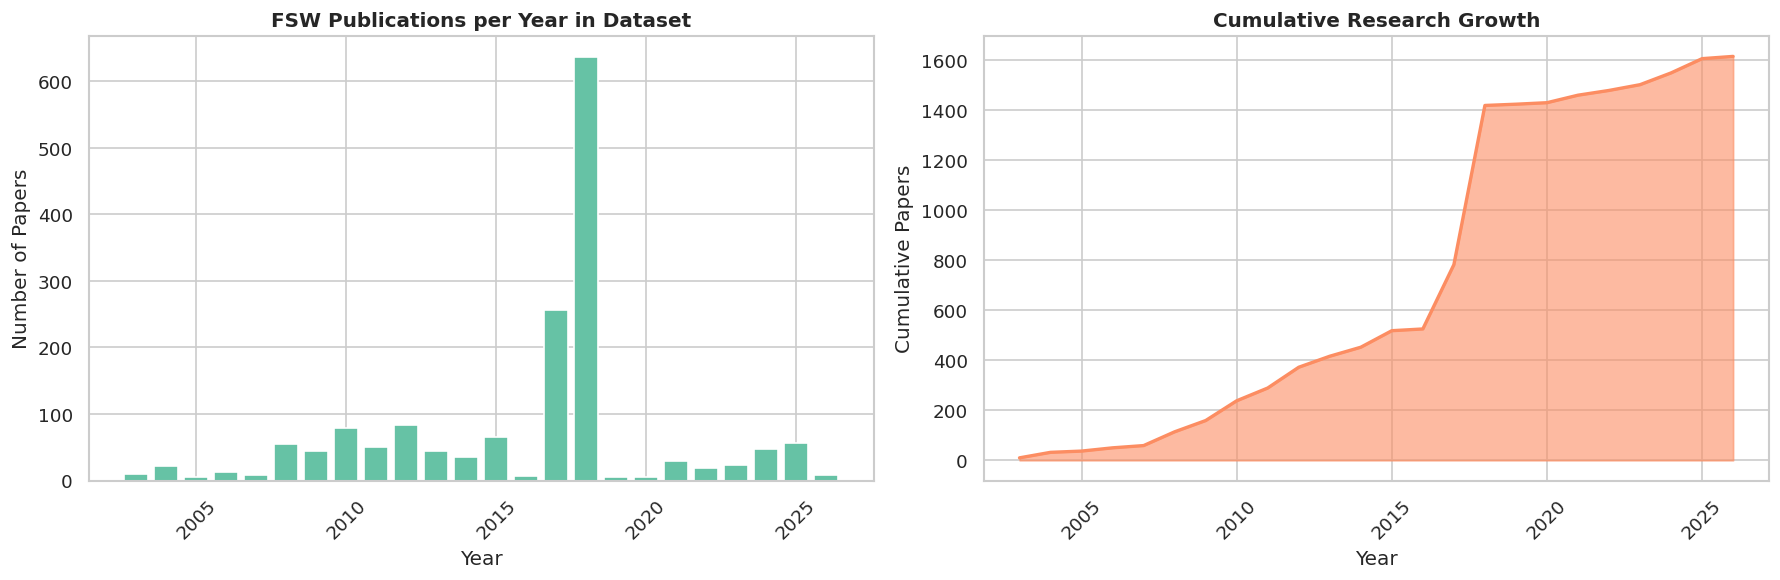

Total unique years: 2003–2026
Peak publication year: 2018 (636 papers)


In [5]:
year_counts = df['Year'].dropna().astype(int).value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Publication volume
axes[0].bar(year_counts.index, year_counts.values, color=COLORS[0], edgecolor='white')
axes[0].set_title('FSW Publications per Year in Dataset', fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Number of Papers')
axes[0].tick_params(axis='x', rotation=45)

# Cumulative
axes[1].fill_between(year_counts.index, year_counts.cumsum().values, alpha=0.6, color=COLORS[1])
axes[1].plot(year_counts.index, year_counts.cumsum().values, color=COLORS[1], linewidth=2)
axes[1].set_title('Cumulative Research Growth', fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Cumulative Papers')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('fig_publication_trends.png', bbox_inches='tight')
plt.show()
print(f'Total unique years: {year_counts.index.min()}–{year_counts.index.max()}')
print(f'Peak publication year: {year_counts.idxmax()} ({year_counts.max()} papers)')

### 3.2 Materials Analysis

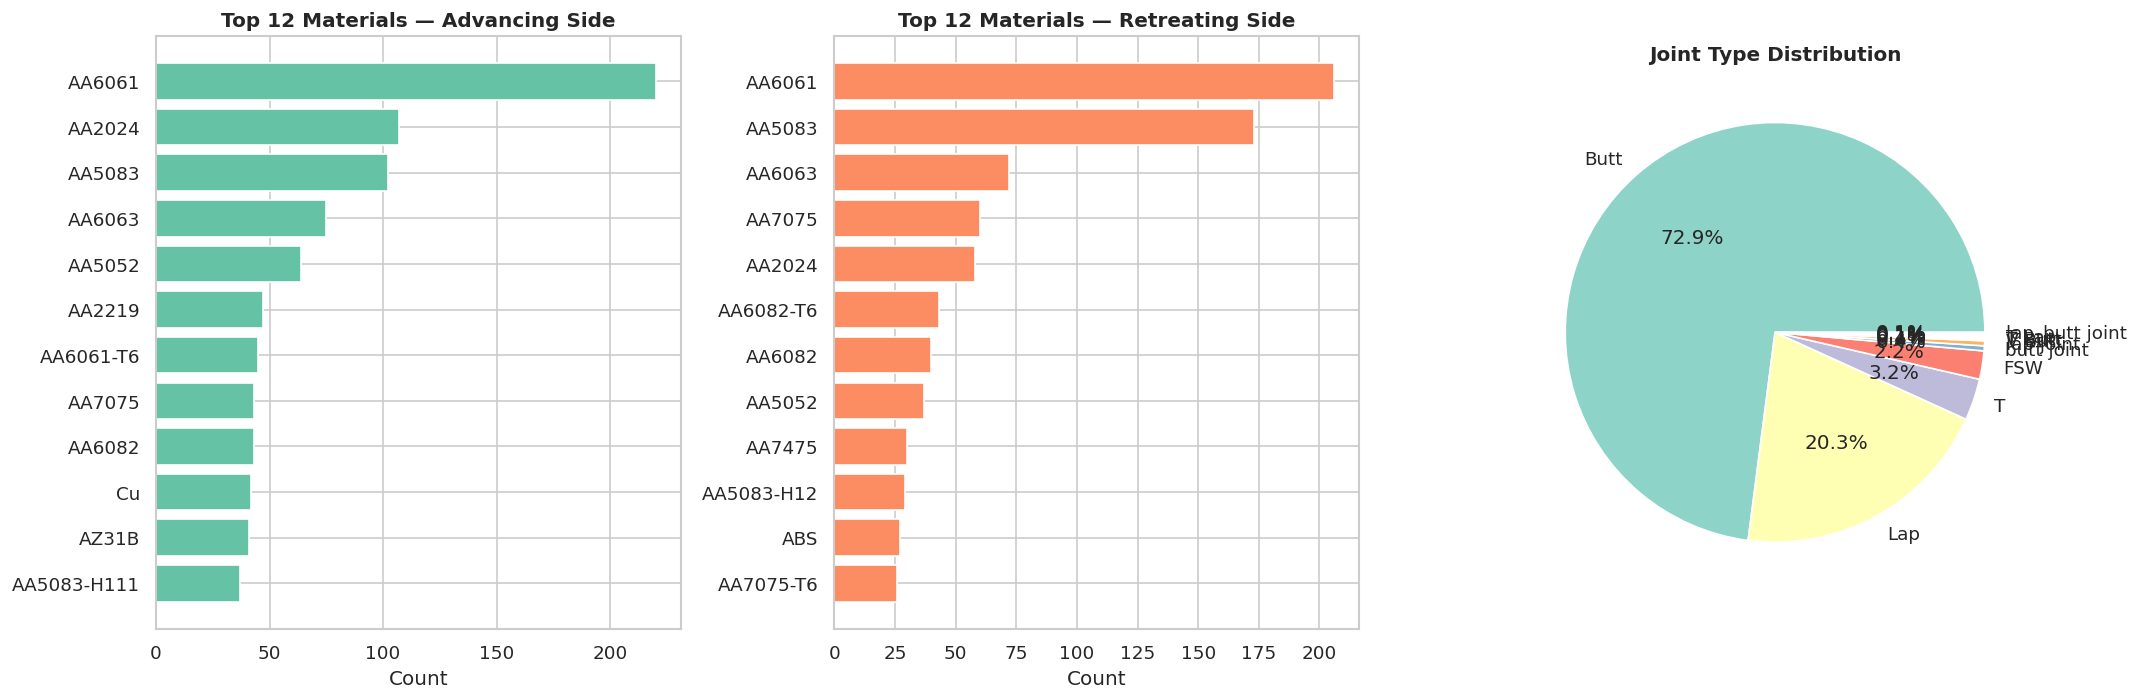

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Top Materials (Advancing Side)
top_as = df['Material_AS'].value_counts().head(12)
axes[0].barh(top_as.index[::-1], top_as.values[::-1], color=COLORS[0])
axes[0].set_title('Top 12 Materials — Advancing Side', fontweight='bold')
axes[0].set_xlabel('Count')

# Top Materials (Retreating Side)
top_rs = df['Material_RS'].value_counts().head(12)
axes[1].barh(top_rs.index[::-1], top_rs.values[::-1], color=COLORS[1])
axes[1].set_title('Top 12 Materials — Retreating Side', fontweight='bold')
axes[1].set_xlabel('Count')

# Joint type distribution
jt = df['Joint_Type'].value_counts()
axes[2].pie(jt.values, labels=jt.index, autopct='%1.1f%%',
            colors=sns.color_palette('Set3', len(jt)))
axes[2].set_title('Joint Type Distribution', fontweight='bold')

plt.tight_layout()
plt.savefig('fig_materials.png', bbox_inches='tight')
plt.show()

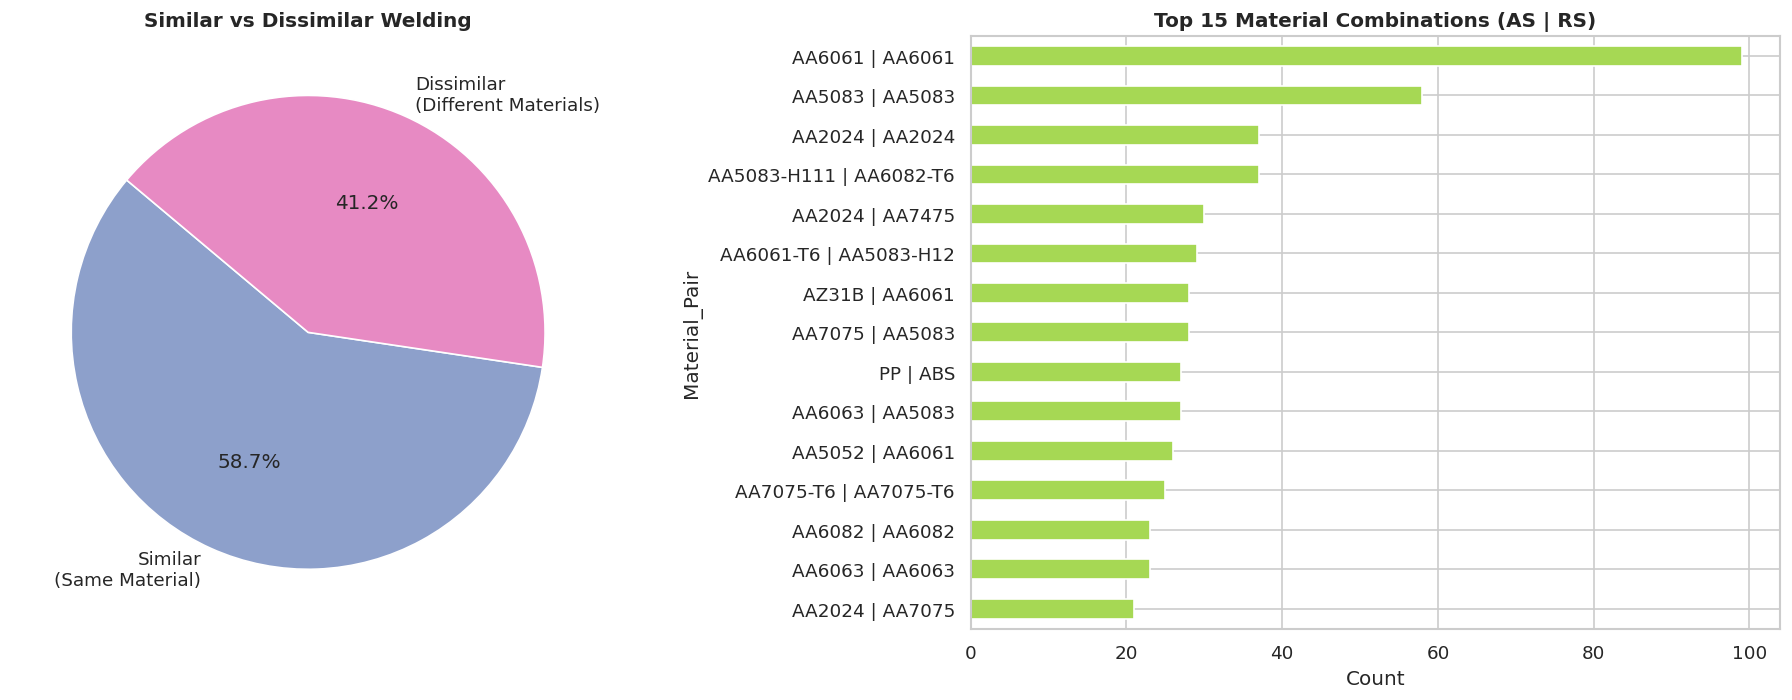

Similar welds: 693 (41.2%)
Dissimilar welds: 987 (58.8%)


In [7]:
# Dissimilar vs Similar welding
df['Is_Dissimilar'] = (df['Material_AS'].fillna('') != df['Material_RS'].fillna(''))
dis_counts = df['Is_Dissimilar'].value_counts()

# Material pair co-occurrence (top combos)
df['Material_Pair'] = df['Material_AS'].fillna('?') + ' | ' + df['Material_RS'].fillna('?')
top_pairs = df['Material_Pair'].value_counts().head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
labels = ['Similar\n(Same Material)', 'Dissimilar\n(Different Materials)']
axes[0].pie(dis_counts.values, labels=labels, autopct='%1.1f%%',
            colors=[COLORS[2], COLORS[3]], startangle=140)
axes[0].set_title('Similar vs Dissimilar Welding', fontweight='bold')

top_pairs.plot(kind='barh', ax=axes[1], color=COLORS[4])
axes[1].set_title('Top 15 Material Combinations (AS | RS)', fontweight='bold')
axes[1].set_xlabel('Count')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('fig_material_pairs.png', bbox_inches='tight')
plt.show()
print(f'Similar welds: {dis_counts[False]} ({dis_counts[False]/len(df)*100:.1f}%)')
print(f'Dissimilar welds: {dis_counts[True]} ({dis_counts[True]/len(df)*100:.1f}%)')

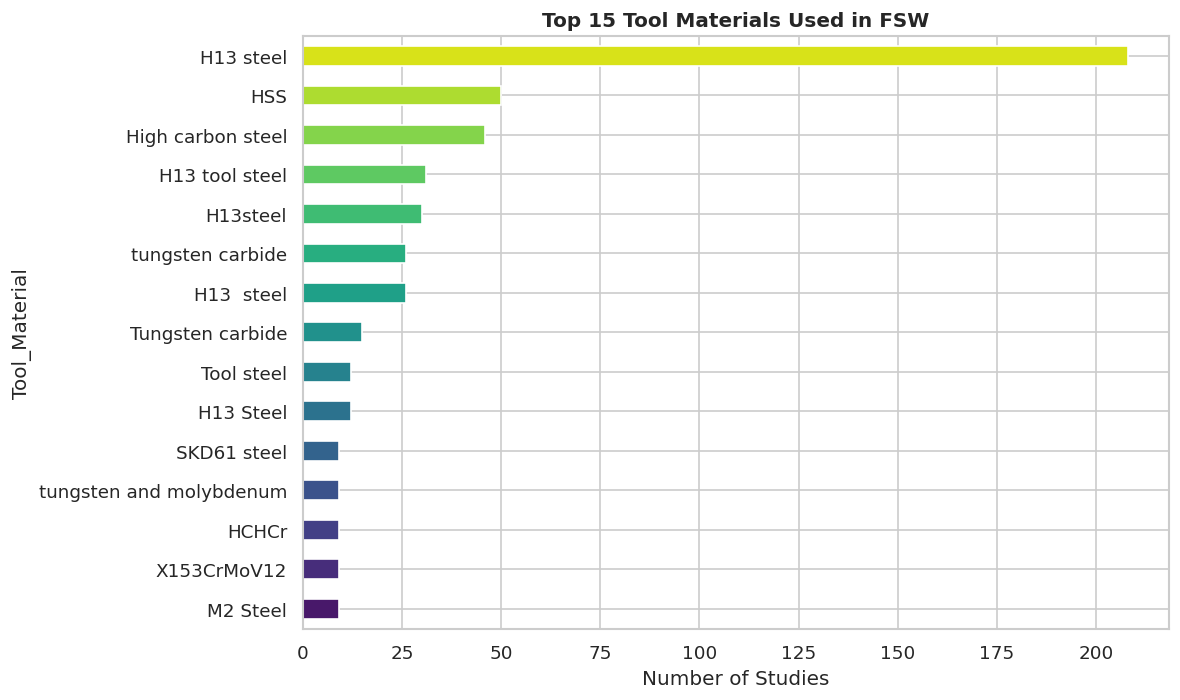

In [8]:
# Tool material usage
tool_counts = df['Tool_Material'].value_counts().head(15)
fig, ax = plt.subplots(figsize=(10, 6))
tool_counts[::-1].plot(kind='barh', ax=ax, color=sns.color_palette('viridis', len(tool_counts)))
ax.set_title('Top 15 Tool Materials Used in FSW', fontweight='bold')
ax.set_xlabel('Number of Studies')
plt.tight_layout()
plt.savefig('fig_tool_materials.png', bbox_inches='tight')
plt.show()

### 3.3 Process Parameter Distributions

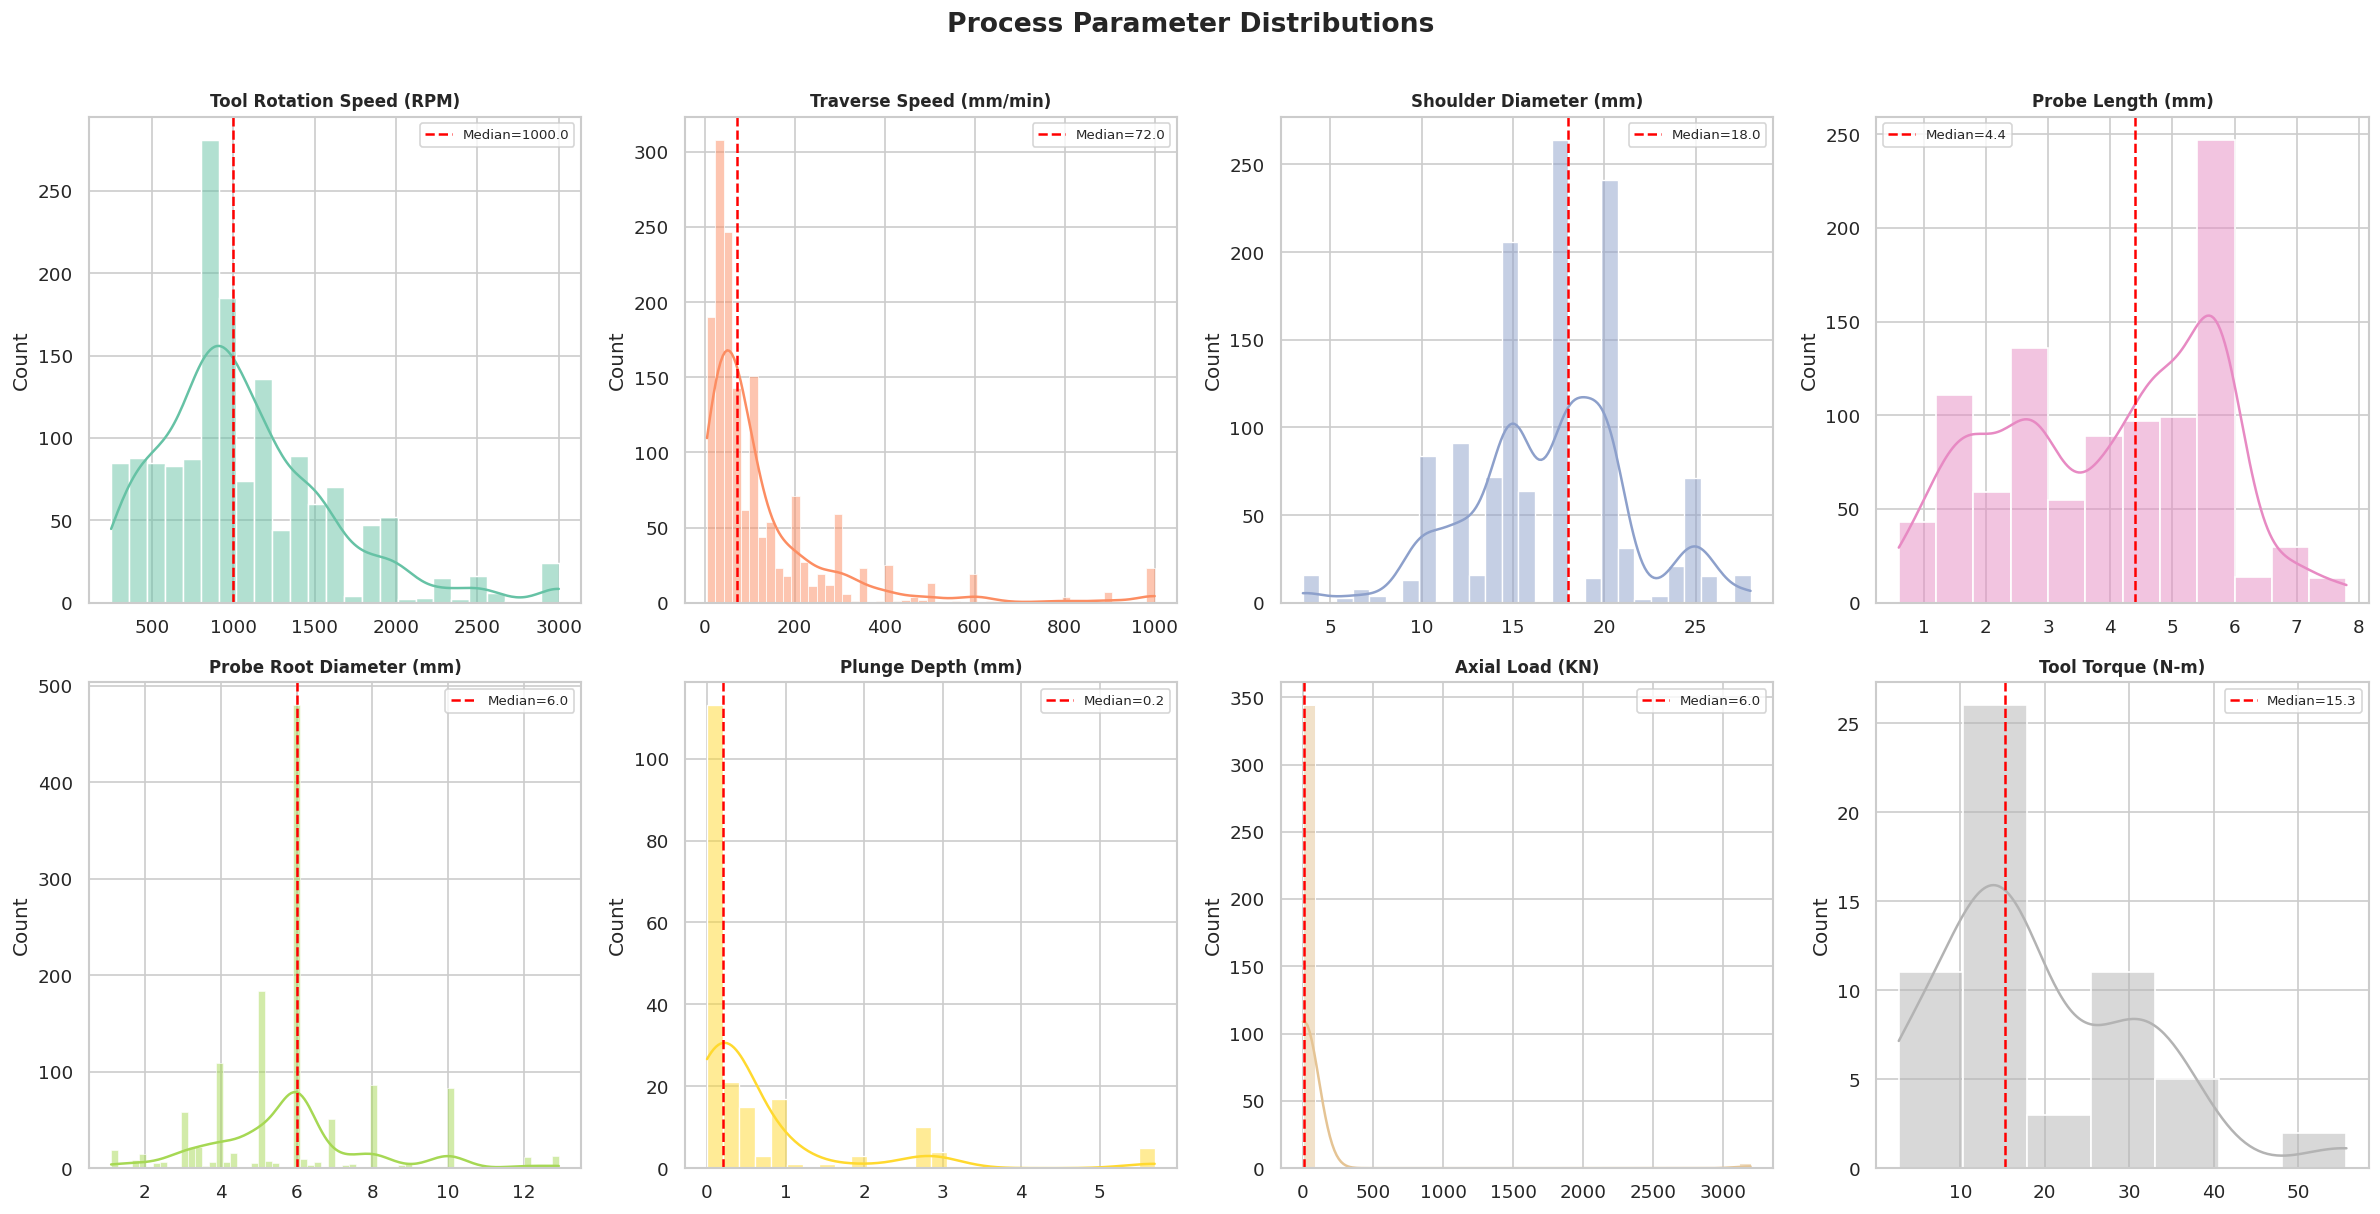

In [9]:
process_params = {
    'Rotation_RPM': 'Tool Rotation Speed (RPM)',
    'Traverse_mmpm': 'Traverse Speed (mm/min)',
    'Shoulder_Dia_mm': 'Shoulder Diameter (mm)',
    'Probe_Length_mm': 'Probe Length (mm)',
    'Probe_Dia_Root_mm': 'Probe Root Diameter (mm)',
    'Plunge_Depth_mm': 'Plunge Depth (mm)',
    'Axial_Load_KN': 'Axial Load (KN)',
    'Torque_Nm': 'Tool Torque (N-m)'
}

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, (col, label) in enumerate(process_params.items()):
    vals = df[col].dropna()
    if len(vals) < 5:
        axes[i].text(0.5, 0.5, 'Insufficient data', ha='center', va='center')
        continue
    # Clip extreme outliers for plotting
    q1, q99 = vals.quantile(0.01), vals.quantile(0.99)
    vals_c = vals.clip(q1, q99)
    sns.histplot(vals_c, ax=axes[i], kde=True, color=COLORS[i % len(COLORS)])
    axes[i].set_title(label, fontweight='bold', fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')
    axes[i].axvline(vals.median(), color='red', linestyle='--', linewidth=1.5, label=f'Median={vals.median():.1f}')
    axes[i].legend(fontsize=8)

plt.suptitle('Process Parameter Distributions', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_process_params.png', bbox_inches='tight')
plt.show()

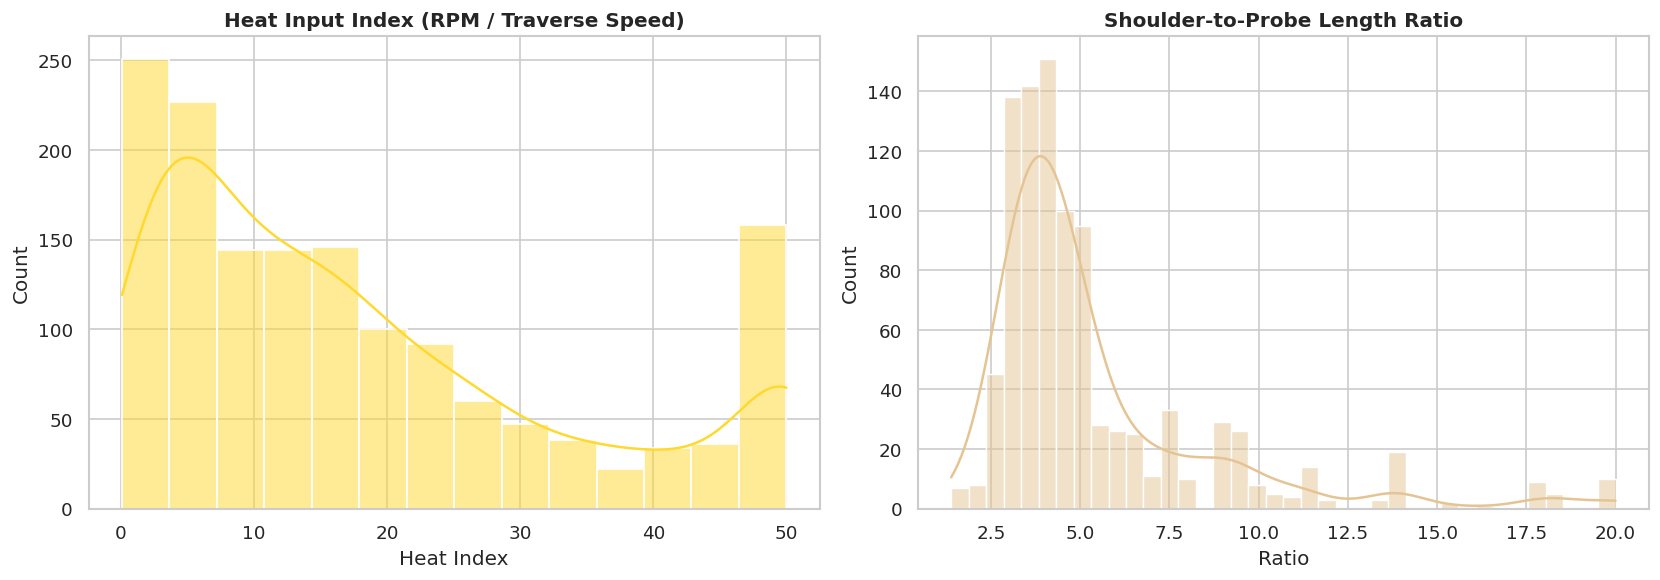


Key derived features:
        Heat_Index  Shoulder_Probe_Ratio
count  1499.000000            957.000000
mean     25.331639              5.490717
std      55.810755              3.572155
min       0.083333              1.384615
25%       5.669643              3.448276
50%      13.750000              4.285714
75%      26.666667              5.882353
max    1000.000000             27.142857


In [10]:
# Welding heat index: H ∝ RPM / Traverse (higher = more heat input)
df['Heat_Index'] = df['Rotation_RPM'] / df['Traverse_mmpm'].replace(0, np.nan)

# Shoulder-to-probe ratio
df['Shoulder_Probe_Ratio'] = df['Shoulder_Dia_mm'] / df['Probe_Length_mm'].replace(0, np.nan)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['Heat_Index'].clip(0, 50), kde=True, ax=axes[0], color=COLORS[5])
axes[0].set_title('Heat Input Index (RPM / Traverse Speed)', fontweight='bold')
axes[0].set_xlabel('Heat Index')

sns.histplot(df['Shoulder_Probe_Ratio'].clip(0, 20), kde=True, ax=axes[1], color=COLORS[6])
axes[1].set_title('Shoulder-to-Probe Length Ratio', fontweight='bold')
axes[1].set_xlabel('Ratio')

plt.tight_layout()
plt.savefig('fig_derived_features.png', bbox_inches='tight')
plt.show()
print('\nKey derived features:')
print(df[['Heat_Index', 'Shoulder_Probe_Ratio']].describe())

### 3.4 Mechanical Properties

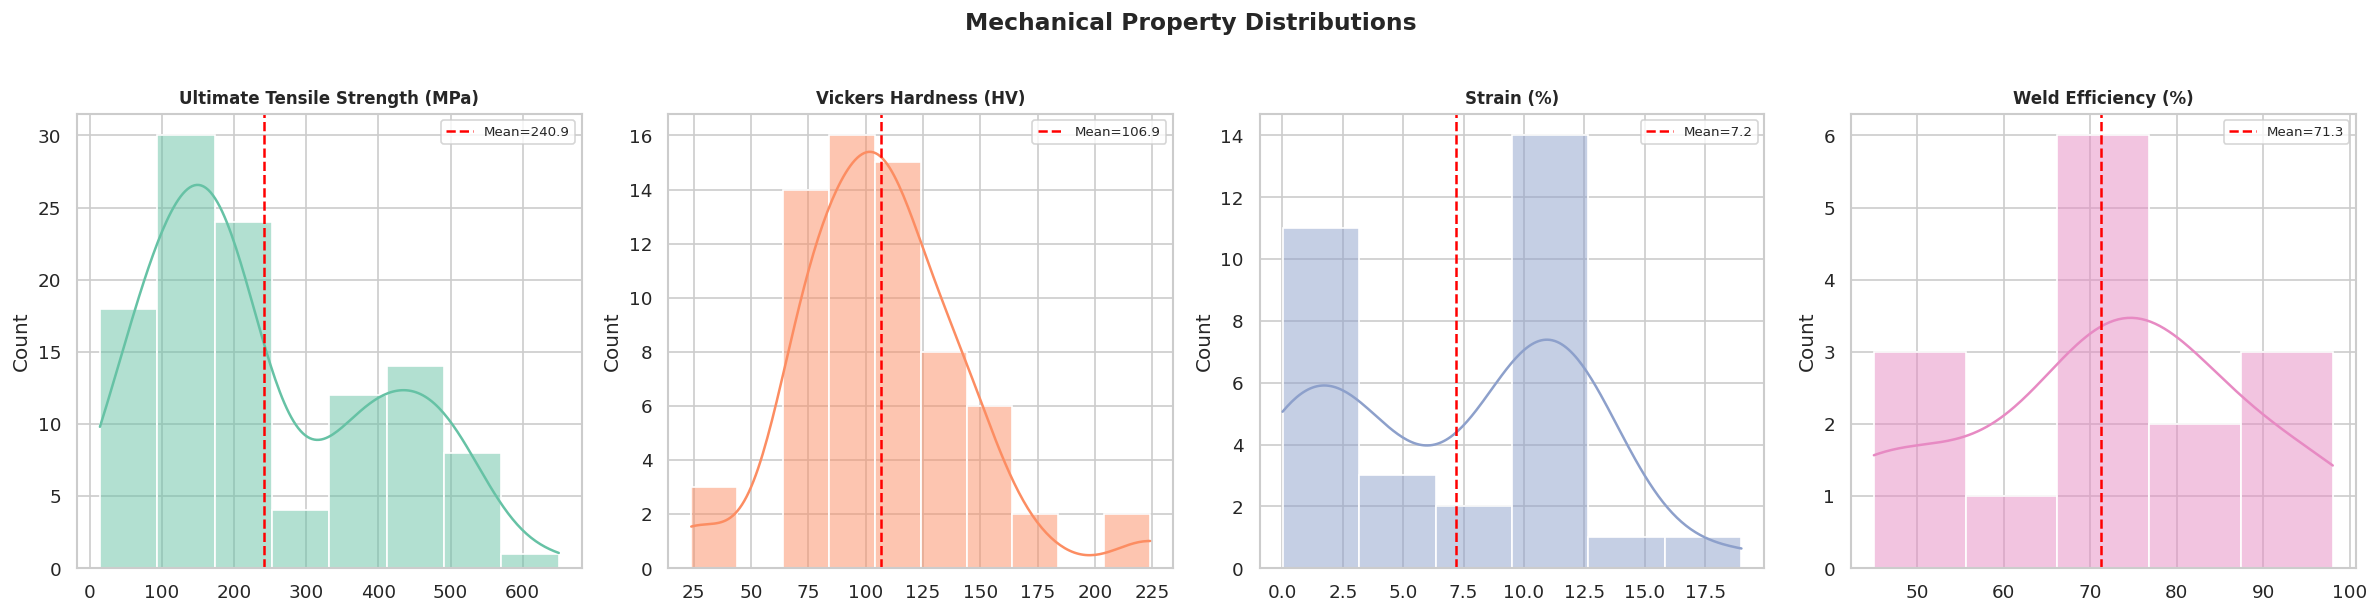


Mechanical Properties Summary:


,UTS_MPa,Hardness_HV,Strain_pct,Weld_Efficiency_pct
count,111.00,66.00,32.00,15.00
mean,240.86,106.92,7.19,71.27
std,155.87,36.82,5.23,17.24
min,14.00,24.00,0.00,45.00
25%,127.25,81.25,1.46,62.50
50%,190.00,103.50,9.55,74.00
75%,380.50,125.15,11.27,78.50
max,650.00,224.00,19.00,98.00


In [11]:
mech_props = {
    'UTS_MPa': 'Ultimate Tensile Strength (MPa)',
    'Hardness_HV': 'Vickers Hardness (HV)',
    'Strain_pct': 'Strain (%)',
    'Weld_Efficiency_pct': 'Weld Efficiency (%)'
}

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for i, (col, label) in enumerate(mech_props.items()):
    vals = df[col].dropna()
    if len(vals) < 5:
        axes[i].text(0.5, 0.5, 'Insufficient data', ha='center', va='center')
        continue
    sns.histplot(vals, kde=True, ax=axes[i], color=COLORS[i])
    axes[i].set_title(label, fontweight='bold', fontsize=10)
    axes[i].set_xlabel('')
    axes[i].axvline(vals.mean(), color='red', linestyle='--', label=f'Mean={vals.mean():.1f}')
    axes[i].legend(fontsize=8)

plt.suptitle('Mechanical Property Distributions', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_mech_props.png', bbox_inches='tight')
plt.show()

print('\nMechanical Properties Summary:')
df[list(mech_props.keys())].describe().round(2)

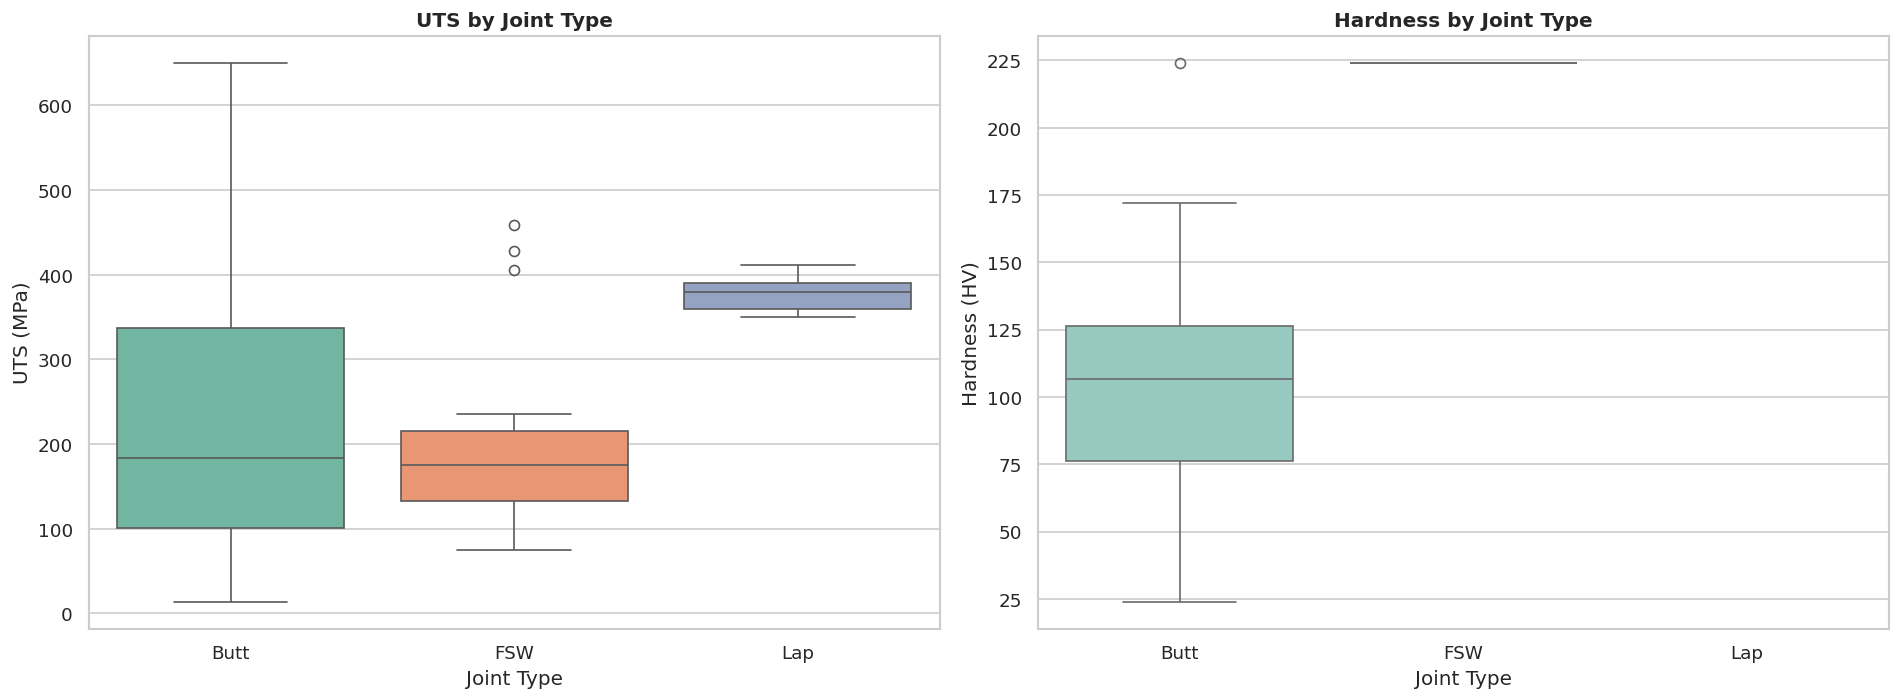

In [12]:
# UTS by Joint Type (boxplot)
uts_joint = df[df['UTS_MPa'].notna() & df['Joint_Type'].notna()]
top_joints = uts_joint['Joint_Type'].value_counts().head(5).index
uts_filt = uts_joint[uts_joint['Joint_Type'].isin(top_joints)]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.boxplot(data=uts_filt, x='Joint_Type', y='UTS_MPa', ax=axes[0],
            palette='Set2', order=top_joints)
axes[0].set_title('UTS by Joint Type', fontweight='bold')
axes[0].set_xlabel('Joint Type')
axes[0].set_ylabel('UTS (MPa)')

# Hardness by joint type
hv_joint = df[df['Hardness_HV'].notna() & df['Joint_Type'].notna()]
hv_filt = hv_joint[hv_joint['Joint_Type'].isin(top_joints)]
sns.boxplot(data=hv_filt, x='Joint_Type', y='Hardness_HV', ax=axes[1],
            palette='Set3', order=top_joints)
axes[1].set_title('Hardness by Joint Type', fontweight='bold')
axes[1].set_xlabel('Joint Type')
axes[1].set_ylabel('Hardness (HV)')

plt.tight_layout()
plt.savefig('fig_mech_by_joint.png', bbox_inches='tight')
plt.show()

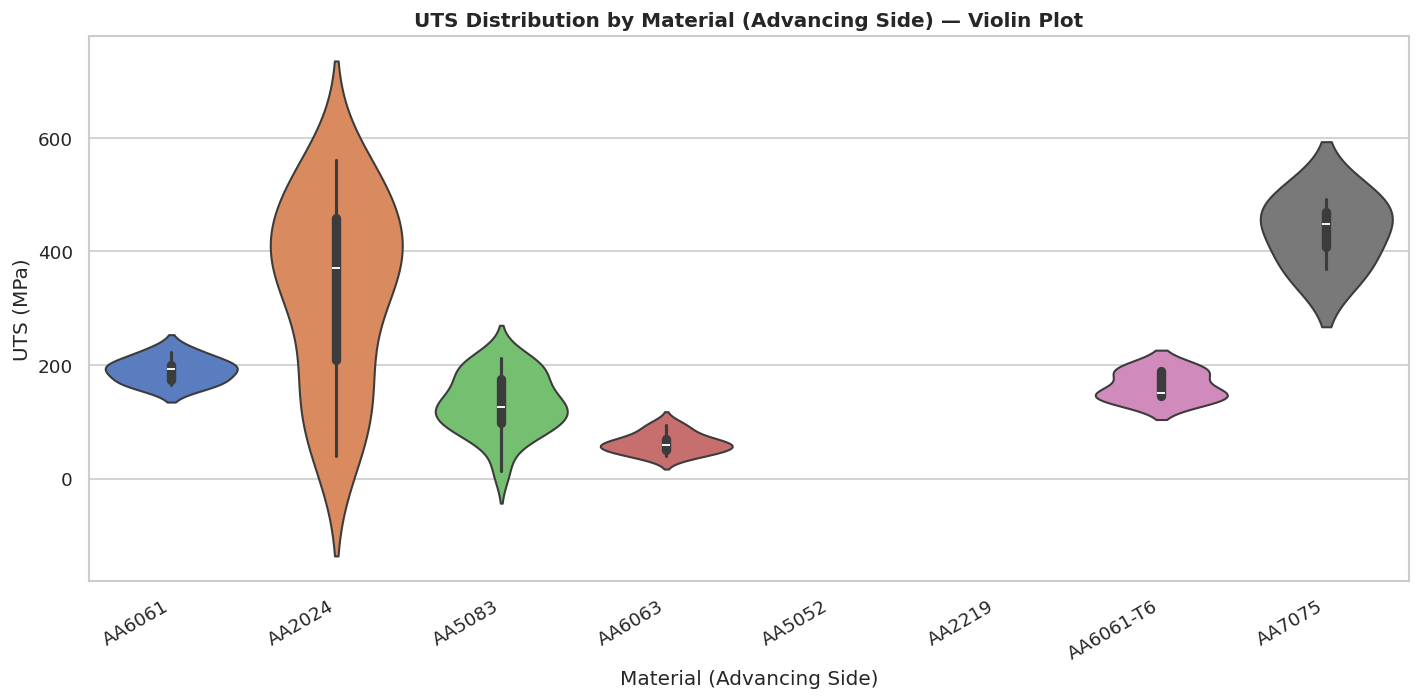

In [13]:
# UTS by top materials
top_mats = df['Material_AS'].value_counts().head(8).index
uts_mat = df[df['UTS_MPa'].notna() & df['Material_AS'].isin(top_mats)]

fig, ax = plt.subplots(figsize=(12, 6))
sns.violinplot(data=uts_mat, x='Material_AS', y='UTS_MPa', ax=ax,
               palette='muted', order=top_mats, inner='box')
ax.set_title('UTS Distribution by Material (Advancing Side) — Violin Plot', fontweight='bold')
ax.set_xlabel('Material (Advancing Side)')
ax.set_ylabel('UTS (MPa)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('fig_uts_by_material.png', bbox_inches='tight')
plt.show()

---
## 4. Statistical Analysis <a id='4'></a>
### 4.1 Correlation Analysis

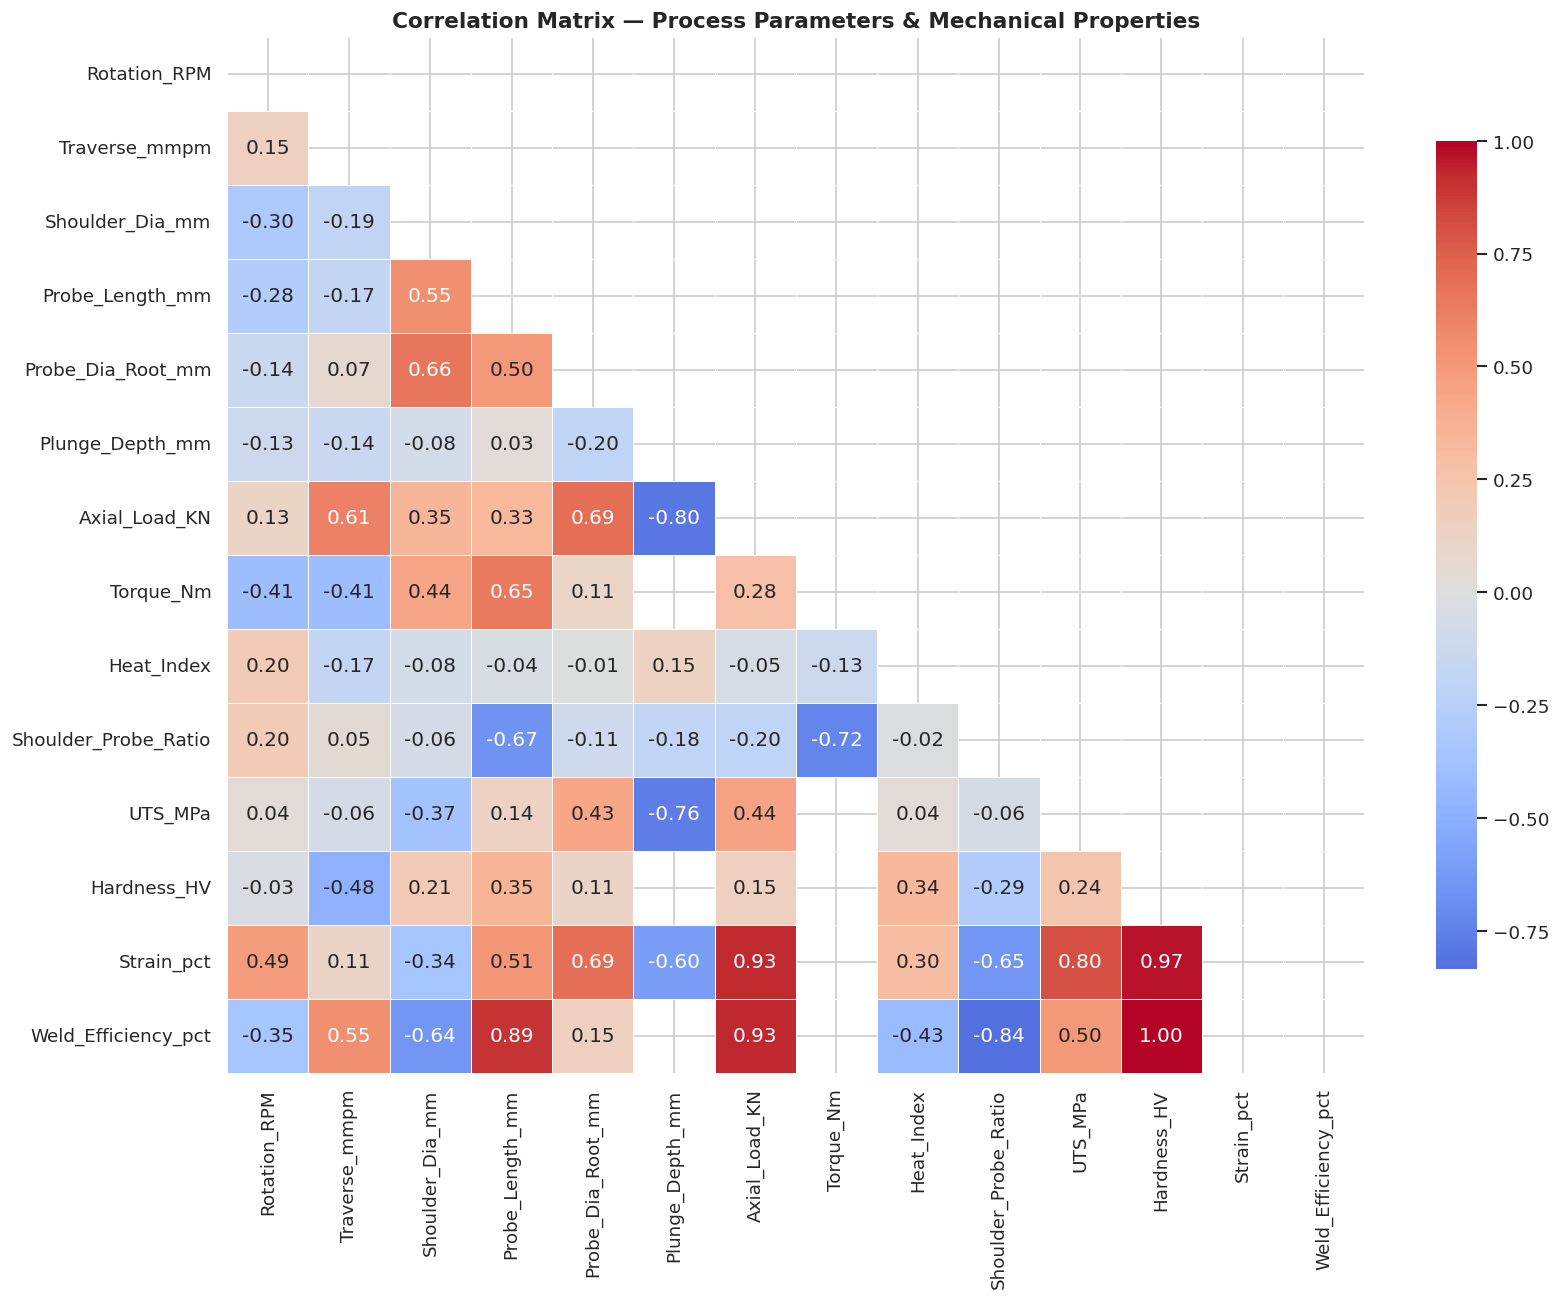


🔍 Top correlations with UTS (MPa):
Strain_pct              0.802
Plunge_Depth_mm        -0.765
Weld_Efficiency_pct     0.499
Axial_Load_KN           0.444
Probe_Dia_Root_mm       0.431
Shoulder_Dia_mm        -0.368
Hardness_HV             0.242
Probe_Length_mm         0.137
Traverse_mmpm          -0.061
Shoulder_Probe_Ratio   -0.060
Rotation_RPM            0.037
Heat_Index              0.035
Torque_Nm                 NaN


In [14]:
corr_cols = ['Rotation_RPM', 'Traverse_mmpm', 'Shoulder_Dia_mm', 'Probe_Length_mm',
             'Probe_Dia_Root_mm', 'Plunge_Depth_mm', 'Axial_Load_KN', 'Torque_Nm',
             'Heat_Index', 'Shoulder_Probe_Ratio',
             'UTS_MPa', 'Hardness_HV', 'Strain_pct', 'Weld_Efficiency_pct']
corr_cols = [c for c in corr_cols if c in df.columns]
corr_df = df[corr_cols].dropna(how='all')

corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, mask=mask, ax=ax, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Matrix — Process Parameters & Mechanical Properties', 
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('fig_correlation.png', bbox_inches='tight')
plt.show()

# Strongest correlations with UTS
if 'UTS_MPa' in corr_matrix.columns:
    uts_corr = corr_matrix['UTS_MPa'].drop('UTS_MPa').sort_values(key=abs, ascending=False)
    print('\n🔍 Top correlations with UTS (MPa):')
    print(uts_corr.round(3).to_string())

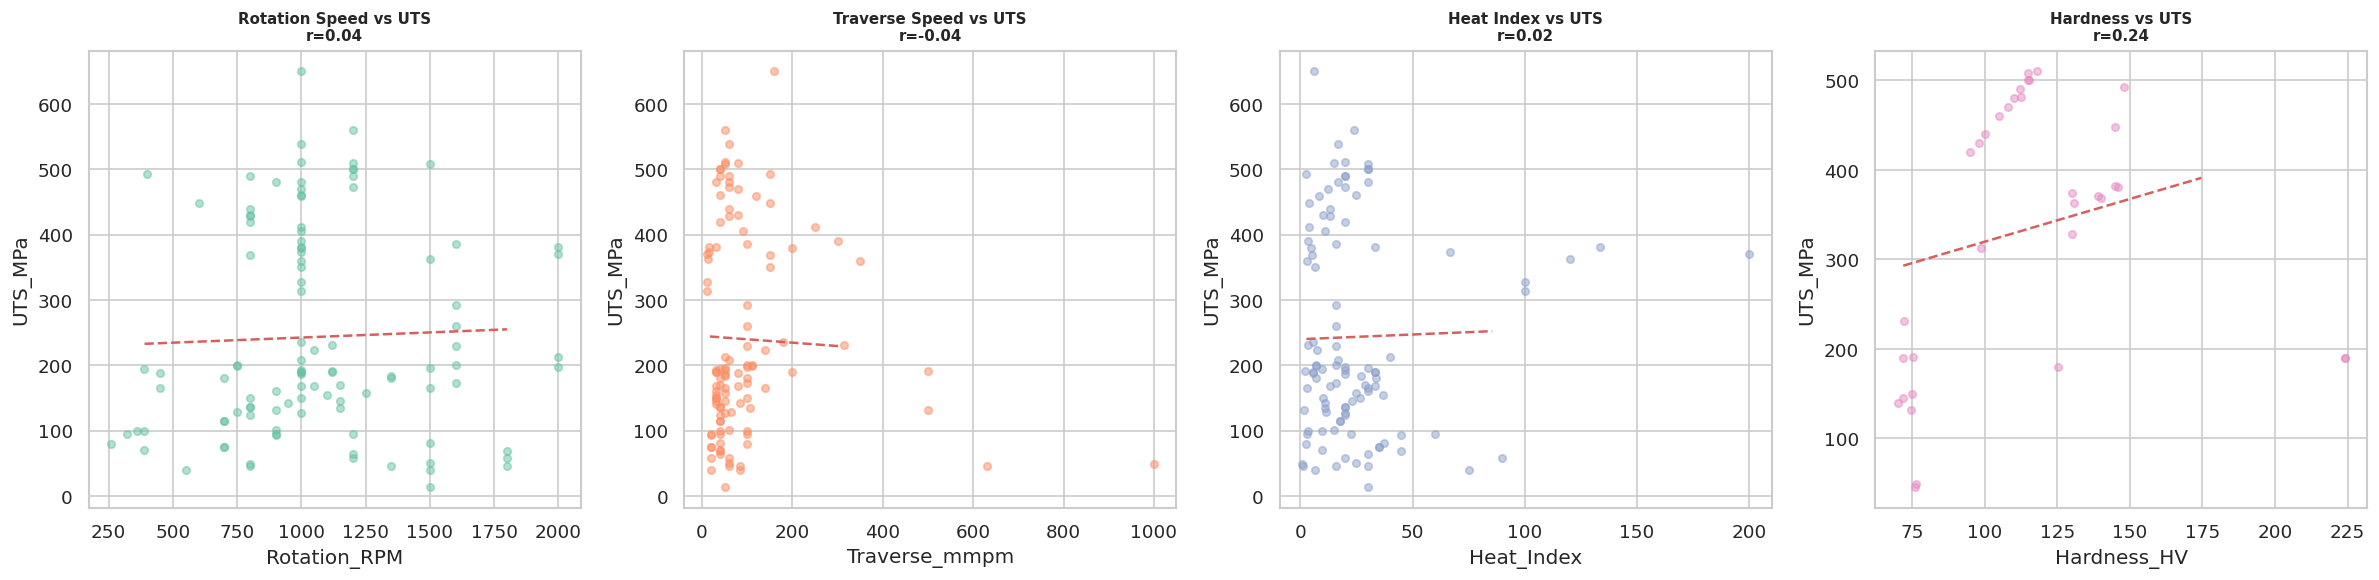

In [15]:
# Scatter plots: Key process params vs UTS
scatter_pairs = [
    ('Rotation_RPM', 'UTS_MPa', 'Rotation Speed vs UTS'),
    ('Traverse_mmpm', 'UTS_MPa', 'Traverse Speed vs UTS'),
    ('Heat_Index', 'UTS_MPa', 'Heat Index vs UTS'),
    ('Hardness_HV', 'UTS_MPa', 'Hardness vs UTS'),
]
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for i, (x, y, title) in enumerate(scatter_pairs):
    sub = df[[x, y]].dropna()
    if len(sub) < 5:
        axes[i].text(0.5, 0.5, 'Not enough data', ha='center', va='center')
        axes[i].set_title(title)
        continue
    axes[i].scatter(sub[x], sub[y], alpha=0.5, s=20, color=COLORS[i])
    z = np.polyfit(sub[x].clip(sub[x].quantile(0.01), sub[x].quantile(0.99)),
                   sub[y].clip(sub[y].quantile(0.01), sub[y].quantile(0.99)), 1)
    p = np.poly1d(z)
    xs = np.linspace(sub[x].quantile(0.05), sub[x].quantile(0.95), 100)
    axes[i].plot(xs, p(xs), 'r--', linewidth=1.5)
    r, pval = stats.pearsonr(sub[x].clip(sub[x].quantile(0.01), sub[x].quantile(0.99)),
                              sub[y].clip(sub[y].quantile(0.01), sub[y].quantile(0.99)))
    axes[i].set_title(f'{title}\nr={r:.2f}', fontweight='bold', fontsize=9)
    axes[i].set_xlabel(x)
    axes[i].set_ylabel(y)

plt.tight_layout()
plt.savefig('fig_scatter_uts.png', bbox_inches='tight')
plt.show()

### 4.2 ANOVA Tests — Do Process Parameters Significantly Differ by Joint Type?

In [16]:
anova_params = ['Rotation_RPM', 'Traverse_mmpm', 'Shoulder_Dia_mm', 'UTS_MPa', 'Hardness_HV']
top_joints_anova = df['Joint_Type'].value_counts().head(4).index.tolist()

print('=== One-Way ANOVA: Process Parameters by Joint Type ===')
print(f'Groups tested: {top_joints_anova}\n')
print(f'{"Parameter":<25} {"F-stat":>10} {"p-value":>12} {"Significant?":>15}')
print('-' * 65)

anova_results = {}
for param in anova_params:
    groups = []
    for jt in top_joints_anova:
        grp = df[df['Joint_Type'] == jt][param].dropna()
        if len(grp) >= 3:
            groups.append(grp)
    if len(groups) >= 2:
        f_stat, p_val = f_oneway(*groups)
        sig = '✅ YES' if p_val < 0.05 else '❌ NO'
        print(f'{param:<25} {f_stat:>10.3f} {p_val:>12.4f} {sig:>15}')
        anova_results[param] = (f_stat, p_val)
    else:
        print(f'{param:<25} {"N/A":>10} {"N/A":>12} {"Not enough groups":>15}')

=== One-Way ANOVA: Process Parameters by Joint Type ===
Groups tested: ['Butt', 'Lap', 'T', 'FSW']

Parameter                     F-stat      p-value    Significant?
-----------------------------------------------------------------
Rotation_RPM                   0.810       0.4887            ❌ NO
Traverse_mmpm                  5.077       0.0017           ✅ YES
Shoulder_Dia_mm               31.319       0.0000           ✅ YES
UTS_MPa                        2.974       0.0555            ❌ NO
Hardness_HV                    0.157       0.6932            ❌ NO


### 4.3 Effect of Rotation Speed Categories on UTS

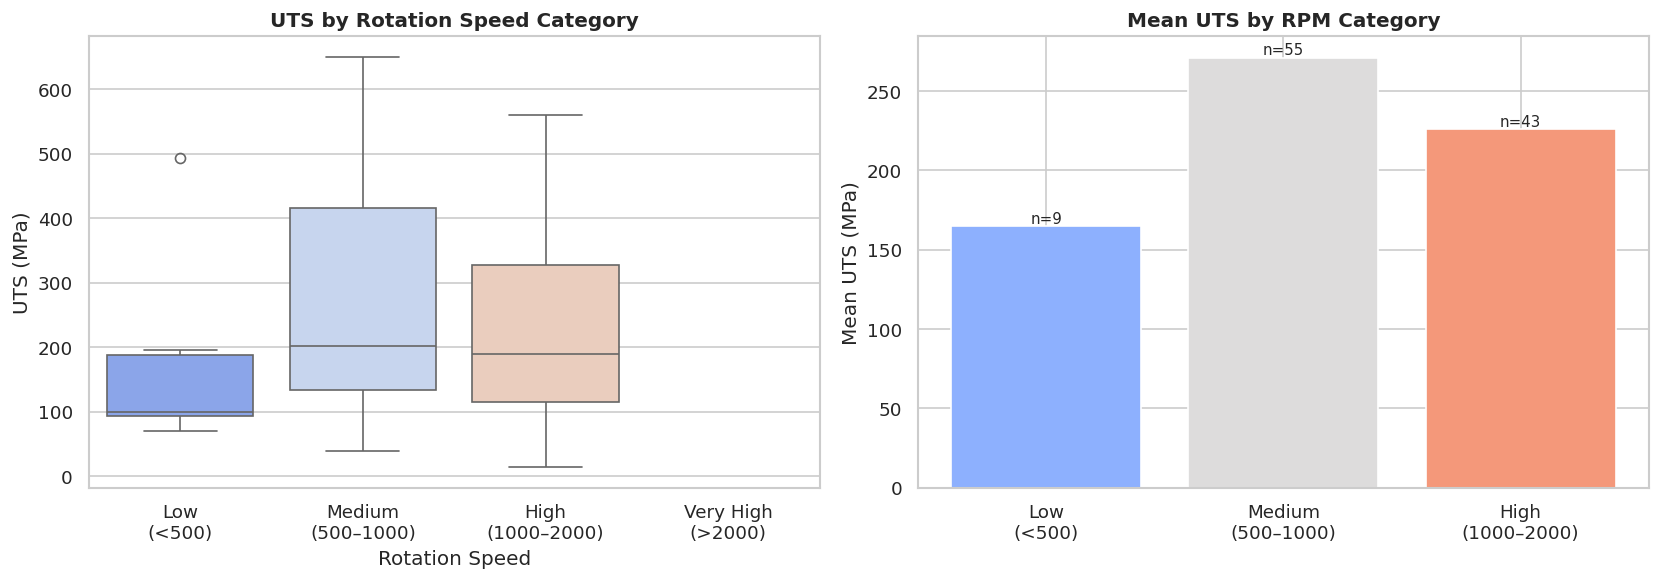

In [17]:
# Bin Rotation RPM into low/medium/high
df['RPM_Category'] = pd.cut(
    df['Rotation_RPM'],
    bins=[0, 500, 1000, 2000, 999999],
    labels=['Low\n(<500)', 'Medium\n(500–1000)', 'High\n(1000–2000)', 'Very High\n(>2000)']
)

rpm_uts = df[df['UTS_MPa'].notna() & df['RPM_Category'].notna()]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=rpm_uts, x='RPM_Category', y='UTS_MPa', ax=axes[0], palette='coolwarm')
axes[0].set_title('UTS by Rotation Speed Category', fontweight='bold')
axes[0].set_xlabel('Rotation Speed')
axes[0].set_ylabel('UTS (MPa)')

# Mean UTS per RPM category
means = rpm_uts.groupby('RPM_Category', observed=True)['UTS_MPa'].mean()
counts = rpm_uts.groupby('RPM_Category', observed=True)['UTS_MPa'].count()
bars = axes[1].bar(means.index, means.values,
                   color=sns.color_palette('coolwarm', len(means)))
for bar, cnt in zip(bars, counts):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                 f'n={cnt}', ha='center', fontsize=9)
axes[1].set_title('Mean UTS by RPM Category', fontweight='bold')
axes[1].set_ylabel('Mean UTS (MPa)')

plt.tight_layout()
plt.savefig('fig_rpm_uts.png', bbox_inches='tight')
plt.show()

---
## 5. Machine Learning — UTS Prediction (Regression) <a id='5'></a>
### 5.1 Feature Engineering for ML

In [18]:
# ── Build ML dataset for UTS prediction ─────────────────────────────────────
# Features: numerical process parameters + encoded categoricals
ML_FEATURES = [
    'Rotation_RPM', 'Traverse_mmpm', 'Shoulder_Dia_mm',
    'Probe_Length_mm', 'Probe_Dia_Root_mm', 'Plunge_Depth_mm',
    'Axial_Load_KN', 'Heat_Index', 'Shoulder_Probe_Ratio',
    'Joint_Type', 'Material_AS'
]
ML_TARGET = 'UTS_MPa'

ml_df = df[ML_FEATURES + [ML_TARGET]].dropna(subset=[ML_TARGET])

# Encode categoricals
cat_cols_ml = ['Joint_Type', 'Material_AS']
ml_encoded = pd.get_dummies(ml_df, columns=cat_cols_ml, drop_first=True)

# Drop rows with too many NaNs in features
ml_encoded = ml_encoded.dropna(subset=[
    'Rotation_RPM', 'Traverse_mmpm'
])

print(f'ML dataset shape: {ml_encoded.shape}')
print(f'Target: {ML_TARGET}')
print(f'\nTarget stats:')
print(ml_encoded[ML_TARGET].describe().round(2))

# Features and target
X = ml_encoded.drop(columns=[ML_TARGET])
y = ml_encoded[ML_TARGET]

# Impute missing feature values with median
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')
X_imp = imputer.fit_transform(X)
feature_names = X.columns.tolist()

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_imp, y, test_size=0.2, random_state=42
)

# Scaling
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print(f'\nTrain size: {len(X_train)}, Test size: {len(X_test)}')

ML dataset shape: (107, 29)
Target: UTS_MPa

Target stats:
count    107.00
mean     243.99
std      157.86
min       14.00
25%      125.28
50%      190.00
75%      381.30
max      650.00
Name: UTS_MPa, dtype: float64

Train size: 85, Test size: 22


### 5.2 Linear Regression (Baseline)

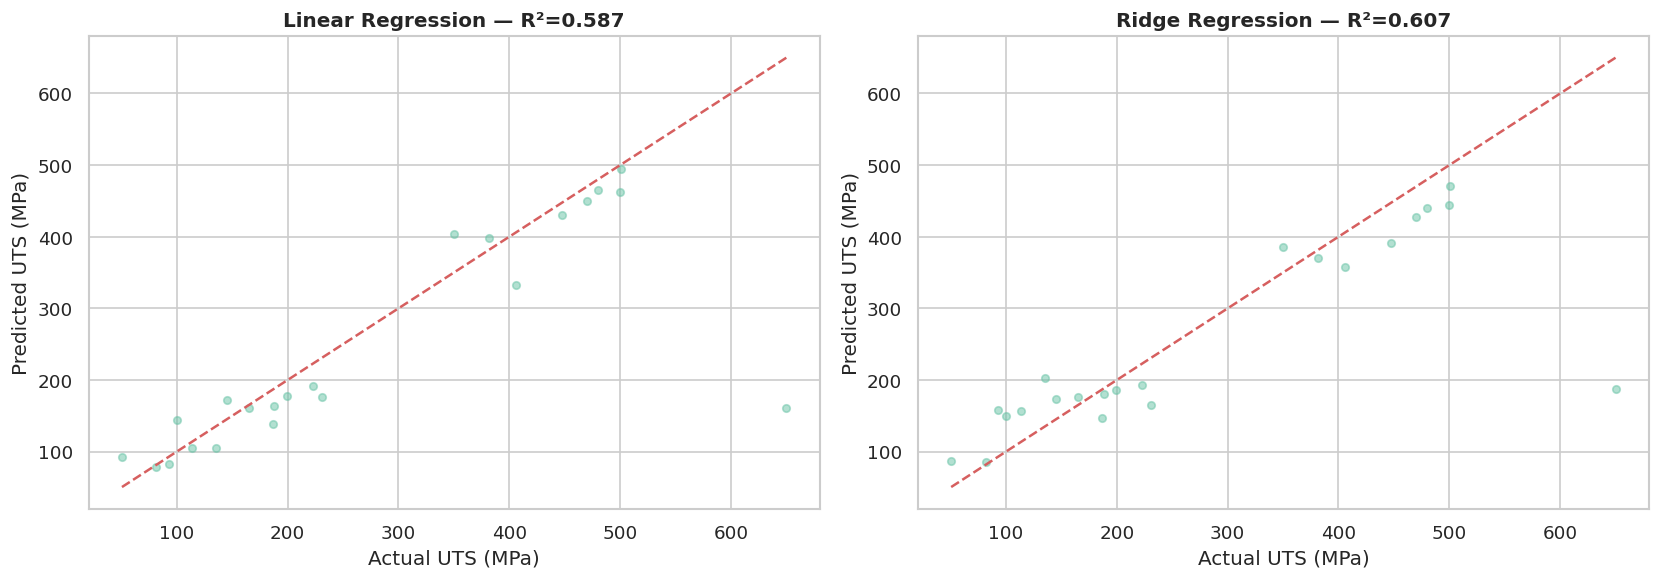

            Model   RMSE   MAE    R²
Linear Regression 109.39 48.92 0.587
 Ridge Regression 106.74 56.47 0.607


In [19]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso

lr = LinearRegression()
lr.fit(X_train_sc, y_train)
y_pred_lr = lr.predict(X_test_sc)

ridge = Ridge(alpha=10)
ridge.fit(X_train_sc, y_train)
y_pred_ridge = ridge.predict(X_test_sc)

def eval_model(y_true, y_pred, name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    return {'Model': name, 'RMSE': round(rmse, 2), 'MAE': round(mae, 2), 'R²': round(r2, 3)}

results = []
results.append(eval_model(y_test, y_pred_lr, 'Linear Regression'))
results.append(eval_model(y_test, y_pred_ridge, 'Ridge Regression'))

# Plot predicted vs actual
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (y_pred, label) in zip(axes, [(y_pred_lr, 'Linear'), (y_pred_ridge, 'Ridge')]):
    ax.scatter(y_test, y_pred, alpha=0.5, s=20, color=COLORS[0])
    mn, mx = min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())
    ax.plot([mn, mx], [mn, mx], 'r--')
    r2 = r2_score(y_test, y_pred)
    ax.set_title(f'{label} Regression — R²={r2:.3f}', fontweight='bold')
    ax.set_xlabel('Actual UTS (MPa)')
    ax.set_ylabel('Predicted UTS (MPa)')

plt.tight_layout()
plt.savefig('fig_linear_pred.png', bbox_inches='tight')
plt.show()
print(pd.DataFrame(results).to_string(index=False))

### 5.3 Random Forest Regressor

Random Forest 5-Fold CV R²: -0.529 ± 0.898


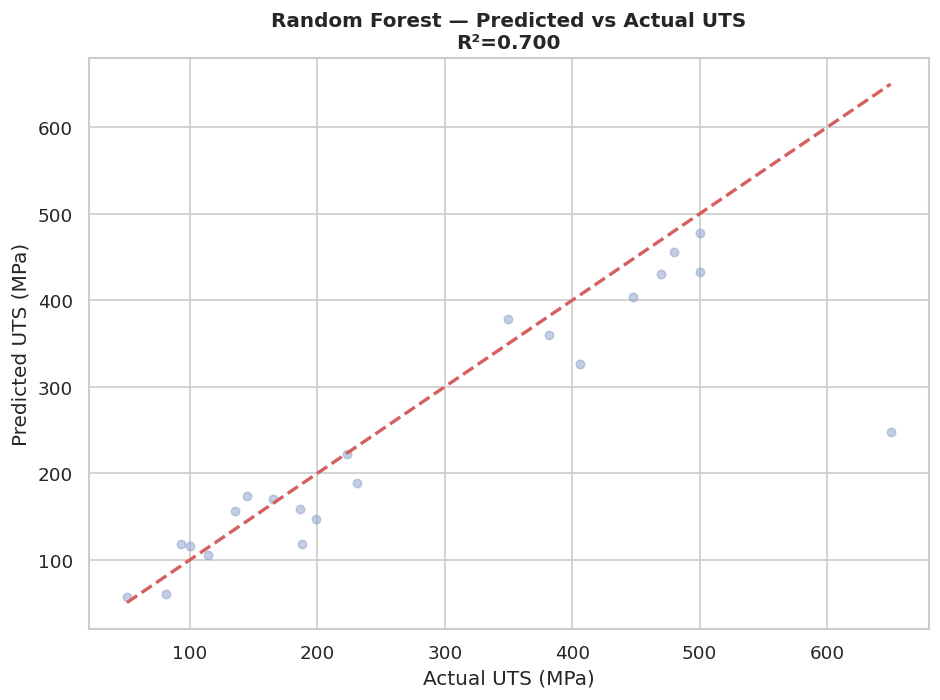

In [20]:
rf = RandomForestRegressor(n_estimators=200, max_depth=10,
                            random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

results.append(eval_model(y_test, y_pred_rf, 'Random Forest'))

# CV score
cv_scores = cross_val_score(rf, X_imp, y, cv=5, scoring='r2', n_jobs=-1)
print(f'Random Forest 5-Fold CV R²: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}')

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_test, y_pred_rf, alpha=0.5, s=25, color=COLORS[2])
mn, mx = min(y_test.min(), y_pred_rf.min()), max(y_test.max(), y_pred_rf.max())
ax.plot([mn, mx], [mn, mx], 'r--', linewidth=2)
r2 = r2_score(y_test, y_pred_rf)
ax.set_title(f'Random Forest — Predicted vs Actual UTS\nR²={r2:.3f}', fontweight='bold')
ax.set_xlabel('Actual UTS (MPa)')
ax.set_ylabel('Predicted UTS (MPa)')
plt.tight_layout()
plt.savefig('fig_rf_pred.png', bbox_inches='tight')
plt.show()

### 5.4 XGBoost Regressor

XGBoost 5-Fold CV R²: -0.548 ± 0.967


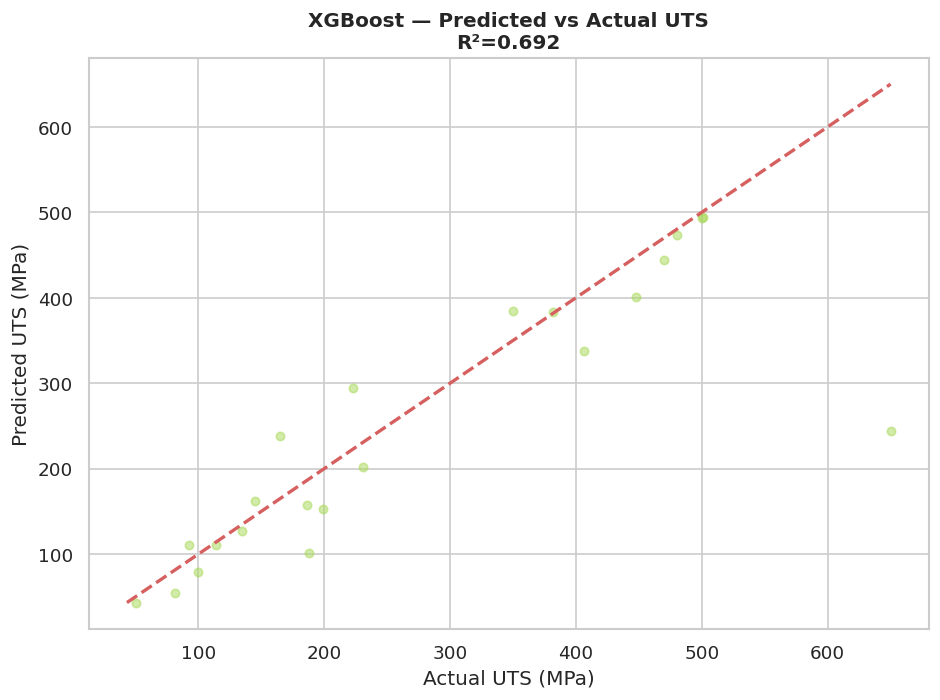

In [21]:
xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0
)
xgb_model.fit(X_train, y_train,
              eval_set=[(X_test, y_test)],
              verbose=False)
y_pred_xgb = xgb_model.predict(X_test)
results.append(eval_model(y_test, y_pred_xgb, 'XGBoost'))

cv_xgb = cross_val_score(xgb_model, X_imp, y, cv=5, scoring='r2', n_jobs=-1)
print(f'XGBoost 5-Fold CV R²: {cv_xgb.mean():.3f} ± {cv_xgb.std():.3f}')

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_test, y_pred_xgb, alpha=0.5, s=25, color=COLORS[4])
mn, mx = min(y_test.min(), y_pred_xgb.min()), max(y_test.max(), y_pred_xgb.max())
ax.plot([mn, mx], [mn, mx], 'r--', linewidth=2)
r2 = r2_score(y_test, y_pred_xgb)
ax.set_title(f'XGBoost — Predicted vs Actual UTS\nR²={r2:.3f}', fontweight='bold')
ax.set_xlabel('Actual UTS (MPa)')
ax.set_ylabel('Predicted UTS (MPa)')
plt.tight_layout()
plt.savefig('fig_xgb_pred.png', bbox_inches='tight')
plt.show()

### 5.5 Model Comparison


📊 Model Performance Summary — UTS Prediction
            Model   RMSE   MAE    R²
Linear Regression 109.39 48.92 0.587
 Ridge Regression 106.74 56.47 0.607
    Random Forest  93.31 47.97 0.700
          XGBoost  94.59 47.18 0.692


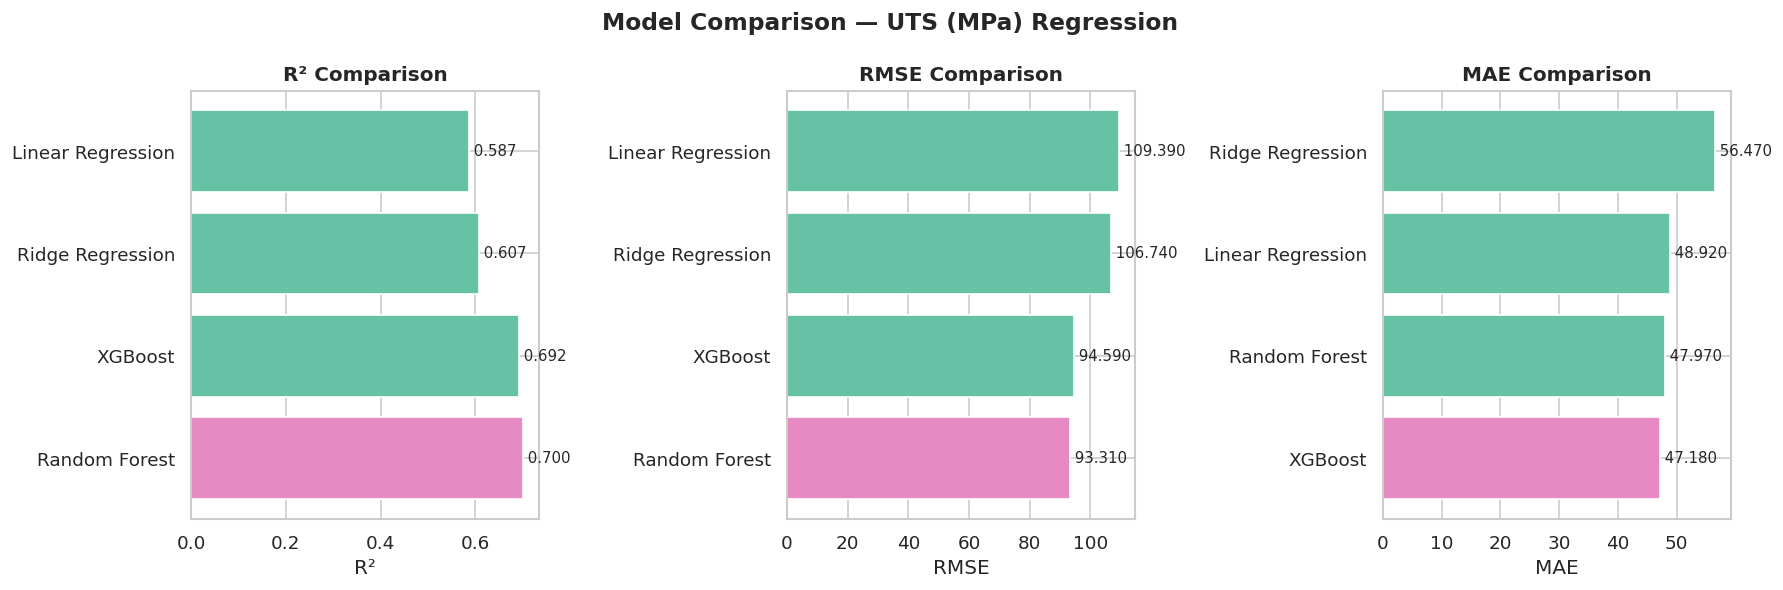

In [22]:
results_df = pd.DataFrame(results)
print('\n📊 Model Performance Summary — UTS Prediction')
print('=' * 55)
print(results_df.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics = ['R²', 'RMSE', 'MAE']
ascending = [False, True, True]  # Higher R² better, lower RMSE/MAE better
for i, (metric, asc) in enumerate(zip(metrics, ascending)):
    sorted_df = results_df.sort_values(metric, ascending=asc)
    colors = [COLORS[3] if m == sorted_df.iloc[0]['Model'] else COLORS[0]
              for m in sorted_df['Model']]
    bars = axes[i].barh(sorted_df['Model'], sorted_df[metric], color=colors)
    axes[i].set_title(f'{metric} Comparison', fontweight='bold')
    axes[i].set_xlabel(metric)
    for bar in bars:
        w = bar.get_width()
        axes[i].text(w, bar.get_y() + bar.get_height()/2,
                     f' {w:.3f}', va='center', fontsize=9)

plt.suptitle('Model Comparison — UTS (MPa) Regression', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_model_comparison.png', bbox_inches='tight')
plt.show()

---
## 6. ML — Hardness Prediction <a id='6'></a>

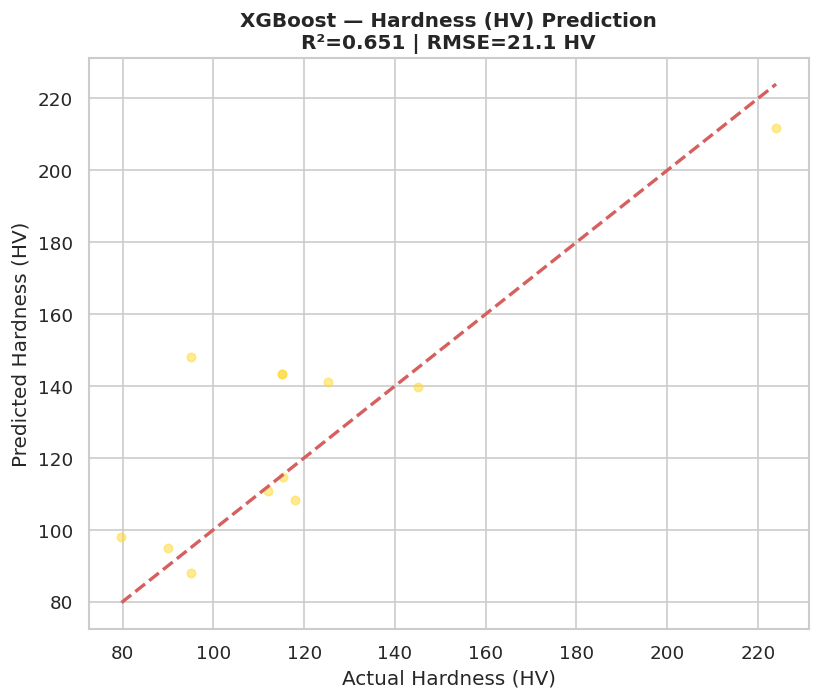

Hardness Prediction — R²: 0.651, RMSE: 21.1 HV, n=12


In [23]:
HV_TARGET = 'Hardness_HV'
HV_FEATURES = [
    'Rotation_RPM', 'Traverse_mmpm', 'Shoulder_Dia_mm',
    'Probe_Length_mm', 'Probe_Dia_Root_mm', 'Plunge_Depth_mm',
    'Heat_Index', 'Shoulder_Probe_Ratio',
    'Joint_Type', 'Material_AS'
]

hv_df = df[HV_FEATURES + [HV_TARGET]].dropna(subset=[HV_TARGET])
hv_enc = pd.get_dummies(hv_df, columns=['Joint_Type', 'Material_AS'], drop_first=True)
hv_enc = hv_enc.dropna(subset=['Rotation_RPM', 'Traverse_mmpm'])

X_hv = hv_enc.drop(columns=[HV_TARGET])
y_hv = hv_enc[HV_TARGET]

imp_hv = SimpleImputer(strategy='median')
X_hv_imp = imp_hv.fit_transform(X_hv)

Xtr_hv, Xte_hv, ytr_hv, yte_hv = train_test_split(X_hv_imp, y_hv, test_size=0.2, random_state=42)

# XGBoost for Hardness
xgb_hv = xgb.XGBRegressor(n_estimators=200, learning_rate=0.08, max_depth=5,
                            random_state=42, verbosity=0)
xgb_hv.fit(Xtr_hv, ytr_hv)
ypred_hv = xgb_hv.predict(Xte_hv)

r2_hv = r2_score(yte_hv, ypred_hv)
rmse_hv = np.sqrt(mean_squared_error(yte_hv, ypred_hv))

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(yte_hv, ypred_hv, alpha=0.5, s=25, color=COLORS[5])
mn, mx = min(yte_hv.min(), ypred_hv.min()), max(yte_hv.max(), ypred_hv.max())
ax.plot([mn, mx], [mn, mx], 'r--', linewidth=2)
ax.set_title(f'XGBoost — Hardness (HV) Prediction\nR²={r2_hv:.3f} | RMSE={rmse_hv:.1f} HV', fontweight='bold')
ax.set_xlabel('Actual Hardness (HV)')
ax.set_ylabel('Predicted Hardness (HV)')
plt.tight_layout()
plt.savefig('fig_hardness_pred.png', bbox_inches='tight')
plt.show()
print(f'Hardness Prediction — R²: {r2_hv:.3f}, RMSE: {rmse_hv:.1f} HV, n={len(yte_hv)}')

---
## 7. Feature Importance & SHAP Analysis <a id='7'></a>

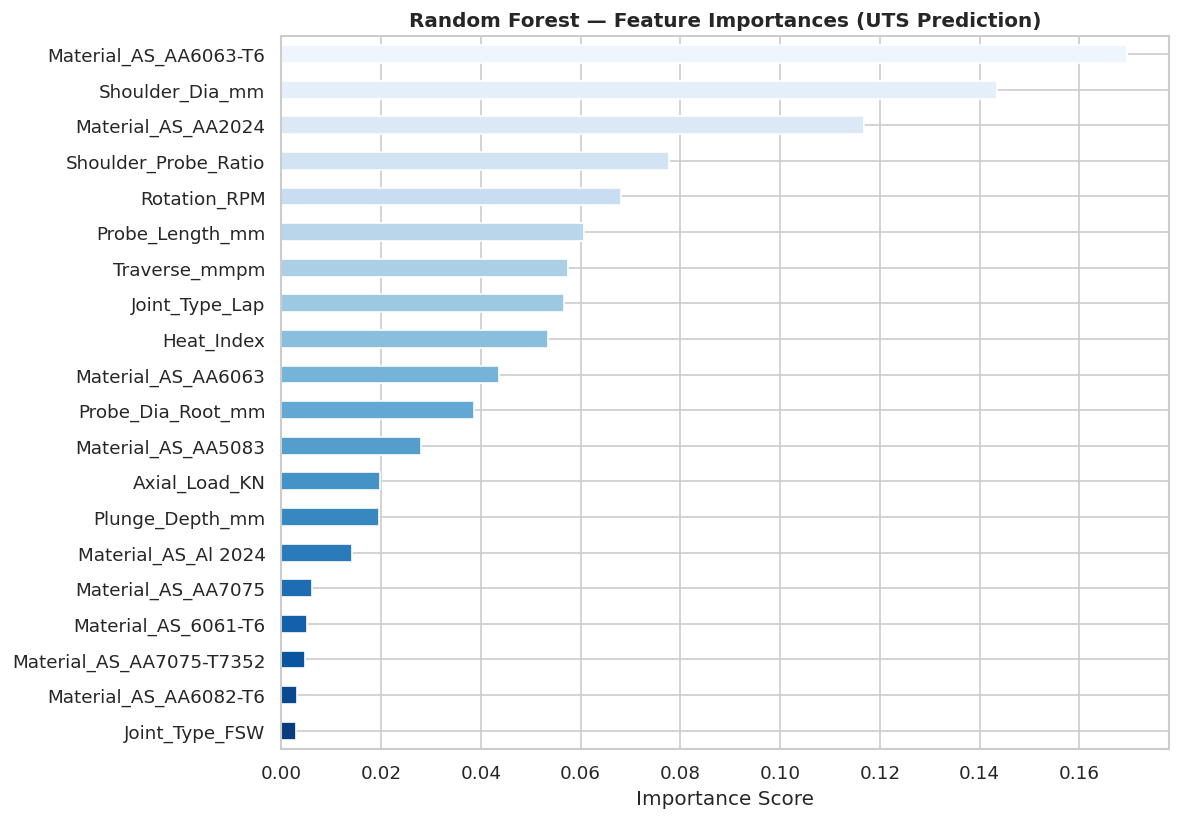

In [24]:
# Feature importances from Random Forest (for UTS)
fi = pd.Series(rf.feature_importances_, index=feature_names)
fi_sorted = fi.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
fi_sorted[::-1].plot(kind='barh', ax=ax,
                     color=sns.color_palette('Blues_r', len(fi_sorted)))
ax.set_title('Random Forest — Feature Importances (UTS Prediction)', fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('fig_feature_importance.png', bbox_inches='tight')
plt.show()

Computing SHAP values (this may take a moment)...


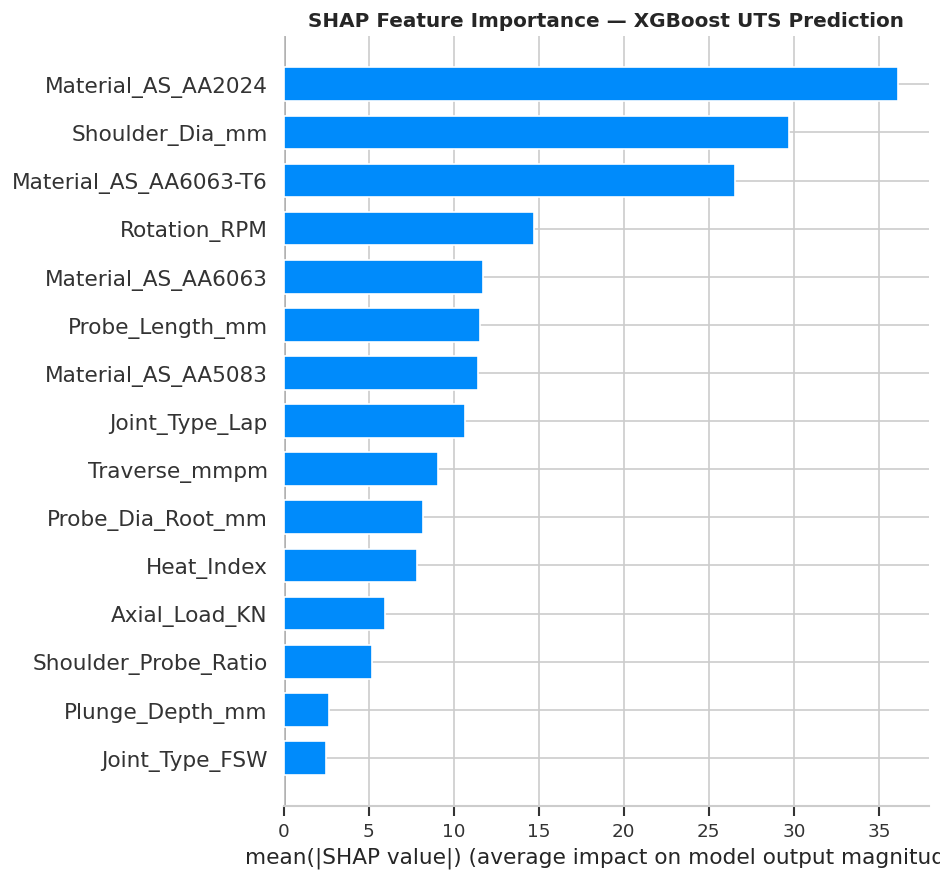

In [25]:
# SHAP analysis — use XGBoost model on a manageable subset
print('Computing SHAP values (this may take a moment)...')
# Use a subset for speed
shap_sample = min(300, len(X_train))
X_shap = X_train[:shap_sample]

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_shap)

fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(shap_values, X_shap, feature_names=feature_names,
                  plot_type='bar', show=False, max_display=15)
plt.title('SHAP Feature Importance — XGBoost UTS Prediction', fontweight='bold')
plt.tight_layout()
plt.savefig('fig_shap_bar.png', bbox_inches='tight')
plt.show()

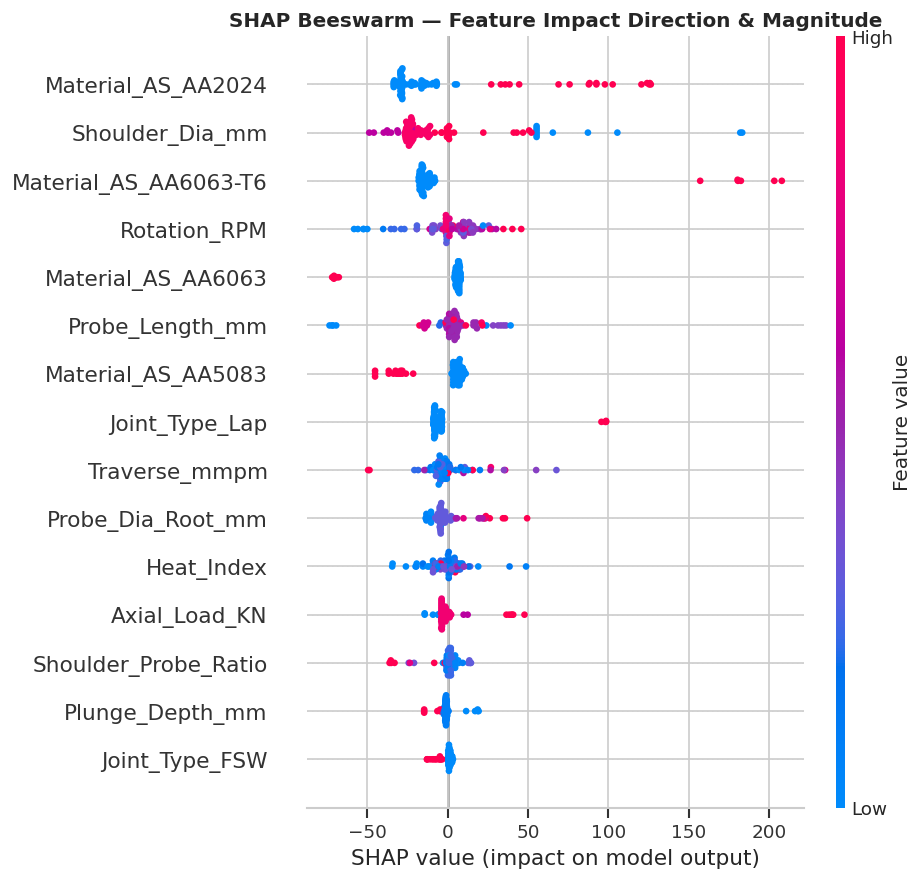


🔬 SHAP Interpretation:
  Red = high feature value, Blue = low feature value
  X-axis = SHAP value (positive = pushes UTS prediction higher)


In [26]:
# SHAP beeswarm plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_shap, feature_names=feature_names,
                  show=False, max_display=15)
plt.title('SHAP Beeswarm — Feature Impact Direction & Magnitude', fontweight='bold')
plt.tight_layout()
plt.savefig('fig_shap_beeswarm.png', bbox_inches='tight')
plt.show()

print('\n🔬 SHAP Interpretation:')
print('  Red = high feature value, Blue = low feature value')
print('  X-axis = SHAP value (positive = pushes UTS prediction higher)')

---
## 8. Clustering — Material & Process Groupings <a id='8'></a>

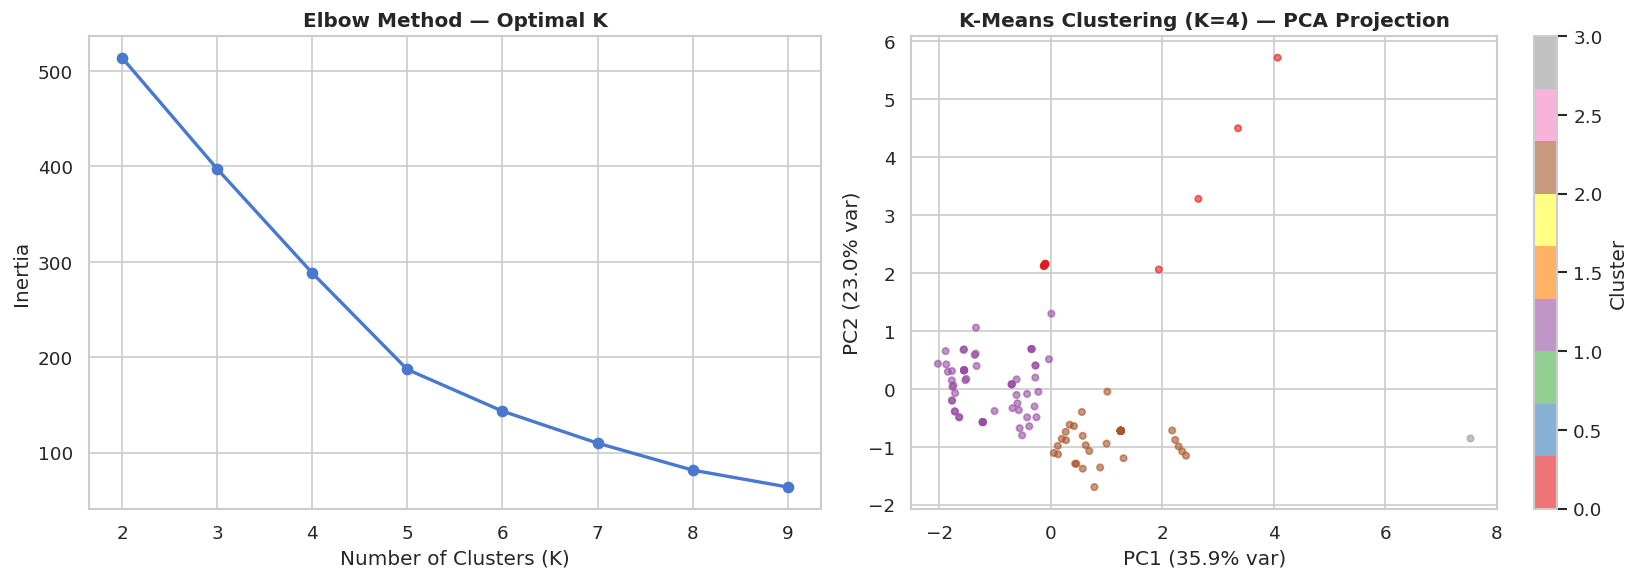


Total variance explained by 2 PCs: 59.0%


In [27]:
# PCA + K-Means clustering on process parameters
cluster_features = ['Rotation_RPM', 'Traverse_mmpm', 'Shoulder_Dia_mm',
                     'Probe_Length_mm', 'Plunge_Depth_mm', 'Heat_Index']
cluster_df = df[cluster_features].dropna()

# Scale
sc_cl = StandardScaler()
X_cl = sc_cl.fit_transform(cluster_df)

# Elbow method
inertias = []
k_range = range(2, 10)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cl)
    inertias.append(km.inertia_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(k_range, inertias, 'bo-', linewidth=2)
axes[0].set_title('Elbow Method — Optimal K', fontweight='bold')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')

# PCA to 2D
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cl)

best_k = 4
km_best = KMeans(n_clusters=best_k, random_state=42, n_init=10)
labels_km = km_best.fit_predict(X_cl)

scatter = axes[1].scatter(X_pca[:, 0], X_pca[:, 1],
                          c=labels_km, cmap='Set1', s=15, alpha=0.6)
plt.colorbar(scatter, ax=axes[1], label='Cluster')
axes[1].set_title(f'K-Means Clustering (K={best_k}) — PCA Projection', fontweight='bold')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')

plt.tight_layout()
plt.savefig('fig_clustering.png', bbox_inches='tight')
plt.show()

print(f'\nTotal variance explained by 2 PCs: {sum(pca.explained_variance_ratio_)*100:.1f}%')

=== Cluster Profiles (Mean Values) ===
         Rotation_RPM  Traverse_mmpm  Shoulder_Dia_mm  Probe_Length_mm  Plunge_Depth_mm  Heat_Index
Cluster                                                                                            
0              2492.3           32.7             17.5              4.1              0.2        72.0
1               947.6           77.5             20.8              6.3              0.8        14.9
2              1400.0          219.3             12.5              1.5              0.4         8.0
3              6000.0         3000.0             12.0              3.5              0.2         2.0


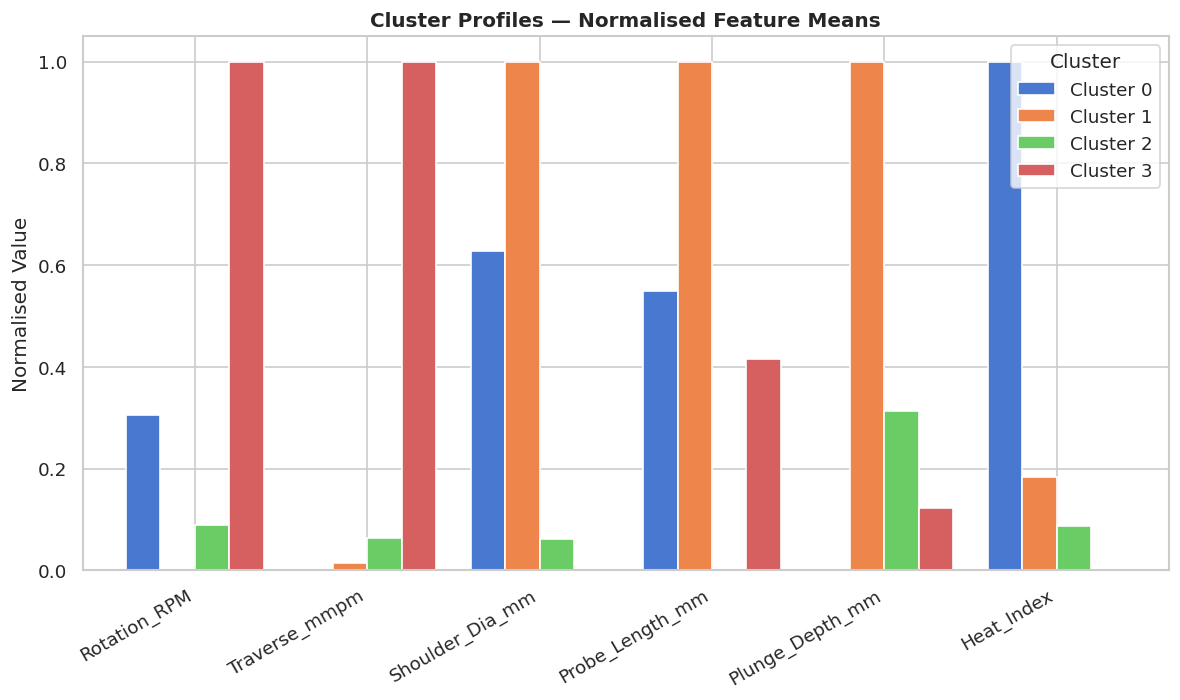

In [28]:
# Analyse cluster characteristics
cluster_df_cp = cluster_df.copy()
cluster_df_cp['Cluster'] = labels_km

print('=== Cluster Profiles (Mean Values) ===')
print(cluster_df_cp.groupby('Cluster')[cluster_features].mean().round(1).to_string())

# Visualise cluster centres
cluster_means = cluster_df_cp.groupby('Cluster')[cluster_features].mean()
fig, ax = plt.subplots(figsize=(10, 6))
cluster_means_norm = (cluster_means - cluster_means.min()) / (cluster_means.max() - cluster_means.min())
cluster_means_norm.T.plot(kind='bar', ax=ax, width=0.8)
ax.set_title('Cluster Profiles — Normalised Feature Means', fontweight='bold')
ax.set_ylabel('Normalised Value')
ax.set_xticklabels(cluster_features, rotation=30, ha='right')
ax.legend(title='Cluster', labels=[f'Cluster {i}' for i in range(best_k)])
plt.tight_layout()
plt.savefig('fig_cluster_profiles.png', bbox_inches='tight')
plt.show()

---
## 9. ML — Classification: Joint Type Prediction <a id='9'></a>

Random Forest Classifier — Accuracy: 97.7%

Class distribution: Butt=527, Lap=137

Classification Report:
              precision    recall  f1-score   support

         Lap       0.90      1.00      0.95        27
        Butt       1.00      0.97      0.99       106

    accuracy                           0.98       133
   macro avg       0.95      0.99      0.97       133
weighted avg       0.98      0.98      0.98       133



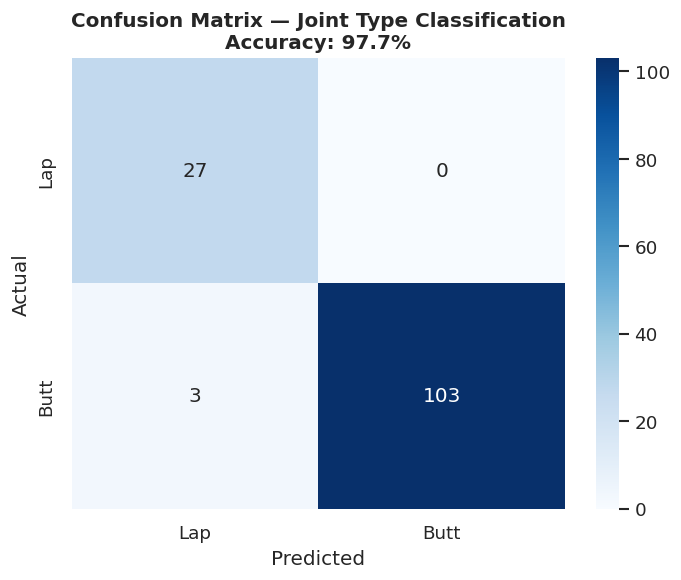

In [29]:
# Binary: Butt vs Lap (the two dominant joint types)
clf_df = df[df['Joint_Type'].isin(['Butt', 'Lap'])].copy()
clf_features = ['Rotation_RPM', 'Traverse_mmpm', 'Shoulder_Dia_mm',
                'Probe_Length_mm', 'Probe_Dia_Root_mm', 'Plunge_Depth_mm', 'Heat_Index']

clf_df = clf_df[clf_features + ['Joint_Type']].dropna(subset=['Rotation_RPM', 'Traverse_mmpm'])

X_clf = clf_df[clf_features]
y_clf = (clf_df['Joint_Type'] == 'Butt').astype(int)  # 1=Butt, 0=Lap

imp_clf = SimpleImputer(strategy='median')
X_clf_imp = imp_clf.fit_transform(X_clf)

Xtr_c, Xte_c, ytr_c, yte_c = train_test_split(X_clf_imp, y_clf, test_size=0.2, random_state=42, stratify=y_clf)

rf_clf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_clf.fit(Xtr_c, ytr_c)
ypred_c = rf_clf.predict(Xte_c)

acc = accuracy_score(yte_c, ypred_c)
print(f'Random Forest Classifier — Accuracy: {acc*100:.1f}%')
print(f'\nClass distribution: Butt={y_clf.sum()}, Lap={len(y_clf)-y_clf.sum()}')
print('\nClassification Report:')
print(classification_report(yte_c, ypred_c, target_names=['Lap', 'Butt']))

# Confusion matrix
cm = confusion_matrix(yte_c, ypred_c)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Lap', 'Butt'], yticklabels=['Lap', 'Butt'])
ax.set_title(f'Confusion Matrix — Joint Type Classification\nAccuracy: {acc*100:.1f}%', fontweight='bold')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig('fig_confusion_matrix.png', bbox_inches='tight')
plt.show()

---
## 10. Parameter Optimization Insights <a id='10'></a>

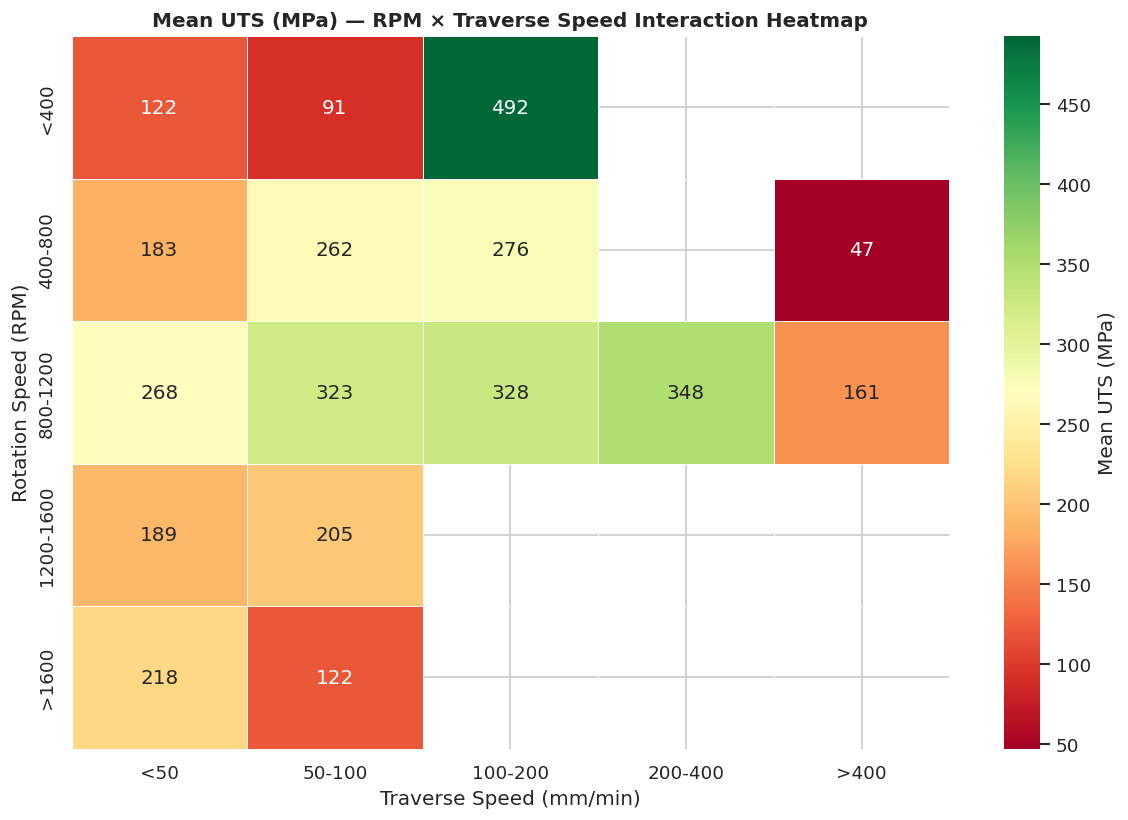

Green zones = higher UTS | Red zones = lower UTS


In [30]:
# Interaction heatmap: RPM x Traverse vs mean UTS
df_opt = df[['Rotation_RPM', 'Traverse_mmpm', 'UTS_MPa']].dropna()

# Bin RPM and Traverse
rpm_bins = [0, 400, 800, 1200, 1600, 3000]
trav_bins = [0, 50, 100, 200, 400, 2000]

df_opt['RPM_bin'] = pd.cut(df_opt['Rotation_RPM'], bins=rpm_bins,
                            labels=['<400', '400-800', '800-1200', '1200-1600', '>1600'])
df_opt['Trav_bin'] = pd.cut(df_opt['Traverse_mmpm'], bins=trav_bins,
                             labels=['<50', '50-100', '100-200', '200-400', '>400'])

pivot = df_opt.groupby(['RPM_bin', 'Trav_bin'], observed=True)['UTS_MPa'].mean().unstack()

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='RdYlGn',
            ax=ax, cbar_kws={'label': 'Mean UTS (MPa)'},
            linewidths=0.5)
ax.set_title('Mean UTS (MPa) — RPM × Traverse Speed Interaction Heatmap', fontweight='bold')
ax.set_xlabel('Traverse Speed (mm/min)')
ax.set_ylabel('Rotation Speed (RPM)')
plt.tight_layout()
plt.savefig('fig_param_optimization.png', bbox_inches='tight')
plt.show()
print('Green zones = higher UTS | Red zones = lower UTS')

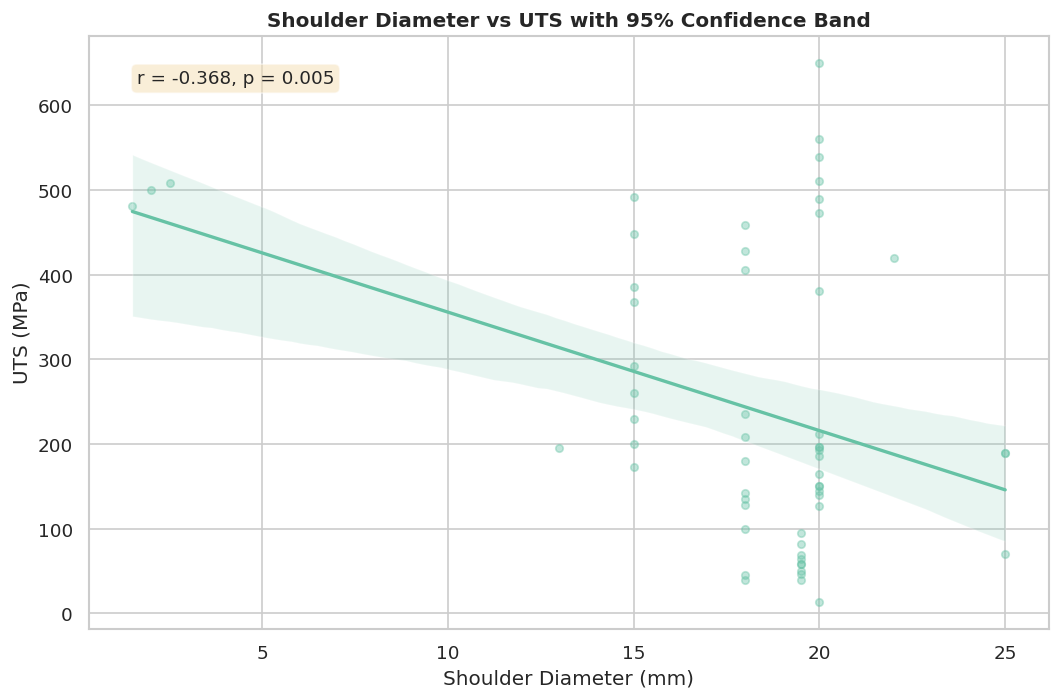

In [31]:
# Shoulder diameter vs UTS: regression with confidence bands
sd_uts = df[['Shoulder_Dia_mm', 'UTS_MPa']].dropna()
sd_uts = sd_uts[(sd_uts['Shoulder_Dia_mm'] < 40) & (sd_uts['UTS_MPa'] < 700)]

fig, ax = plt.subplots(figsize=(9, 6))
sns.regplot(data=sd_uts, x='Shoulder_Dia_mm', y='UTS_MPa', ax=ax,
            scatter_kws={'alpha': 0.4, 's': 20}, color=COLORS[0],
            line_kws={'linewidth': 2})
ax.set_title('Shoulder Diameter vs UTS with 95% Confidence Band', fontweight='bold')
ax.set_xlabel('Shoulder Diameter (mm)')
ax.set_ylabel('UTS (MPa)')
r, p = stats.pearsonr(sd_uts['Shoulder_Dia_mm'], sd_uts['UTS_MPa'])
ax.text(0.05, 0.92, f'r = {r:.3f}, p = {p:.3f}',
        transform=ax.transAxes, fontsize=11, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
plt.tight_layout()
plt.savefig('fig_shoulder_uts.png', bbox_inches='tight')
plt.show()

In [32]:
# Top performing parameter combinations
top_uts = df[['Material_AS', 'Joint_Type', 'Rotation_RPM', 'Traverse_mmpm',
              'Shoulder_Dia_mm', 'UTS_MPa']].dropna(subset=['UTS_MPa'])
top_uts_sorted = top_uts.nlargest(15, 'UTS_MPa')

print('🏆 Top 15 Experiments by UTS (MPa)')
print('=' * 80)
print(top_uts_sorted.to_string(index=False))

🏆 Top 15 Experiments by UTS (MPa)
Material_AS Joint_Type  Rotation_RPM  Traverse_mmpm  Shoulder_Dia_mm  UTS_MPa
     AA2014       Butt        1000.0          160.2             20.0   650.00
     AA2024        NaN        1200.0           50.0             20.0   560.10
     AA2024        NaN        1000.0           60.0             20.0   539.42
     AA2024        NaN        1000.0           50.0             20.0   511.02
  AA6063-T6       Butt        1200.0           80.0              NaN   510.00
    Al 2024       Butt        1500.0           50.0              2.5   508.30
    Al 2024       Butt        1200.0           40.0              2.0   500.60
  AA6063-T6       Butt        1200.0           40.0              NaN   500.00
     AA7075       Butt         400.0          150.0             15.0   492.30
  AA6063-T6       Butt        1200.0           60.0              NaN   490.00
     AA2024        NaN         800.0           40.0             20.0   490.00
    Al 2024       Butt        

---
## 11. Research Gaps & Recommendations <a id='11'></a>

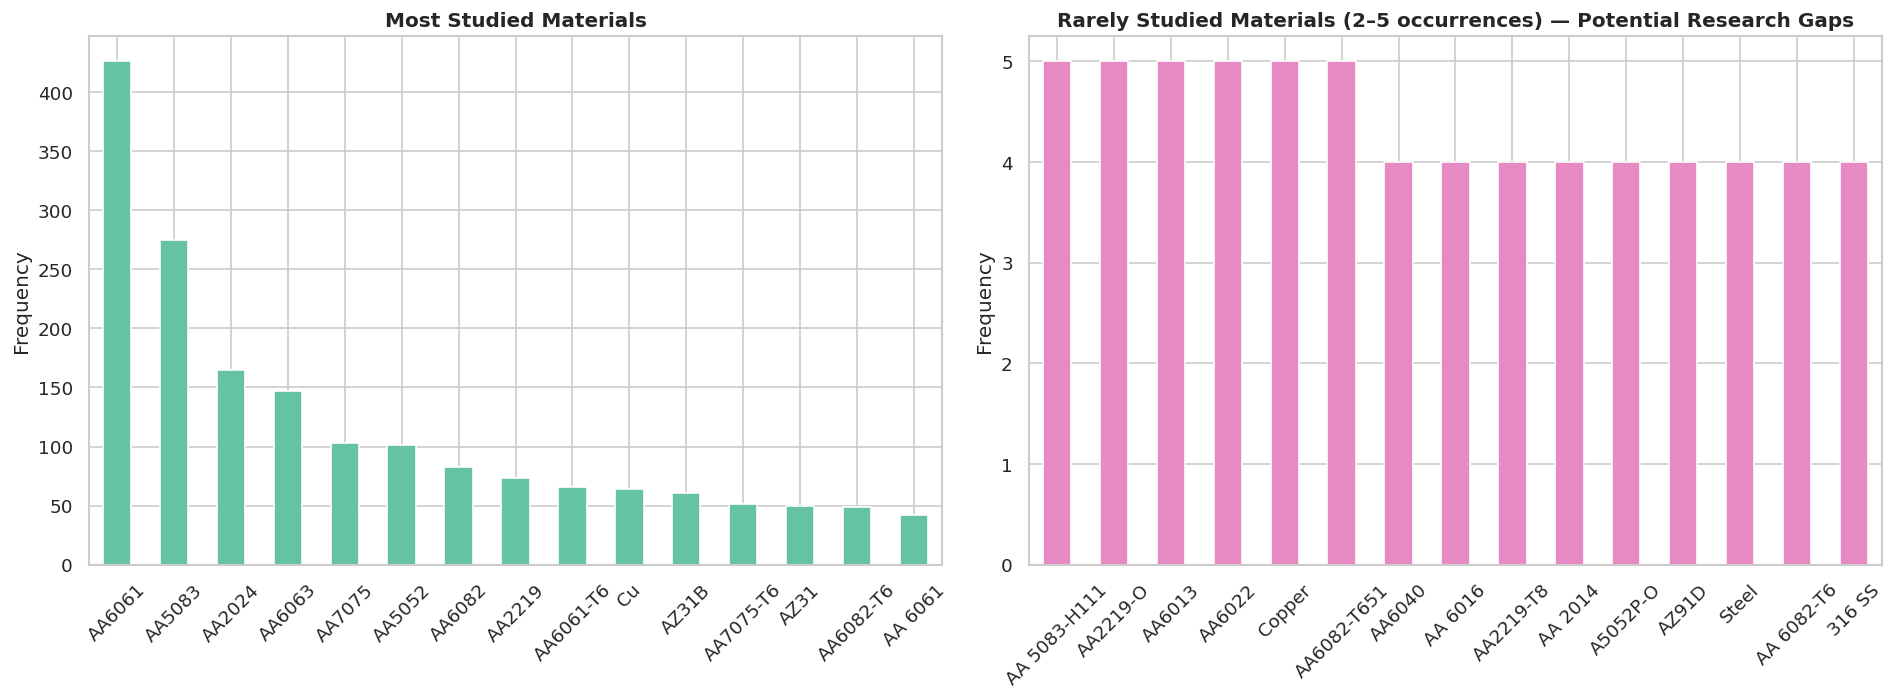

In [33]:
# Identify under-explored materials
all_mats = pd.concat([df['Material_AS'], df['Material_RS']]).dropna()
mat_freq = all_mats.value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top studied
mat_freq.head(15).plot(kind='bar', ax=axes[0], color=COLORS[0])
axes[0].set_title('Most Studied Materials', fontweight='bold')
axes[0].set_ylabel('Frequency')
axes[0].tick_params(axis='x', rotation=45)

# Rarely studied
rare = mat_freq[(mat_freq <= 5) & (mat_freq >= 2)].head(15)
rare.plot(kind='bar', ax=axes[1], color=COLORS[3])
axes[1].set_title('Rarely Studied Materials (2–5 occurrences) — Potential Research Gaps', fontweight='bold')
axes[1].set_ylabel('Frequency')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('fig_research_gaps.png', bbox_inches='tight')
plt.show()

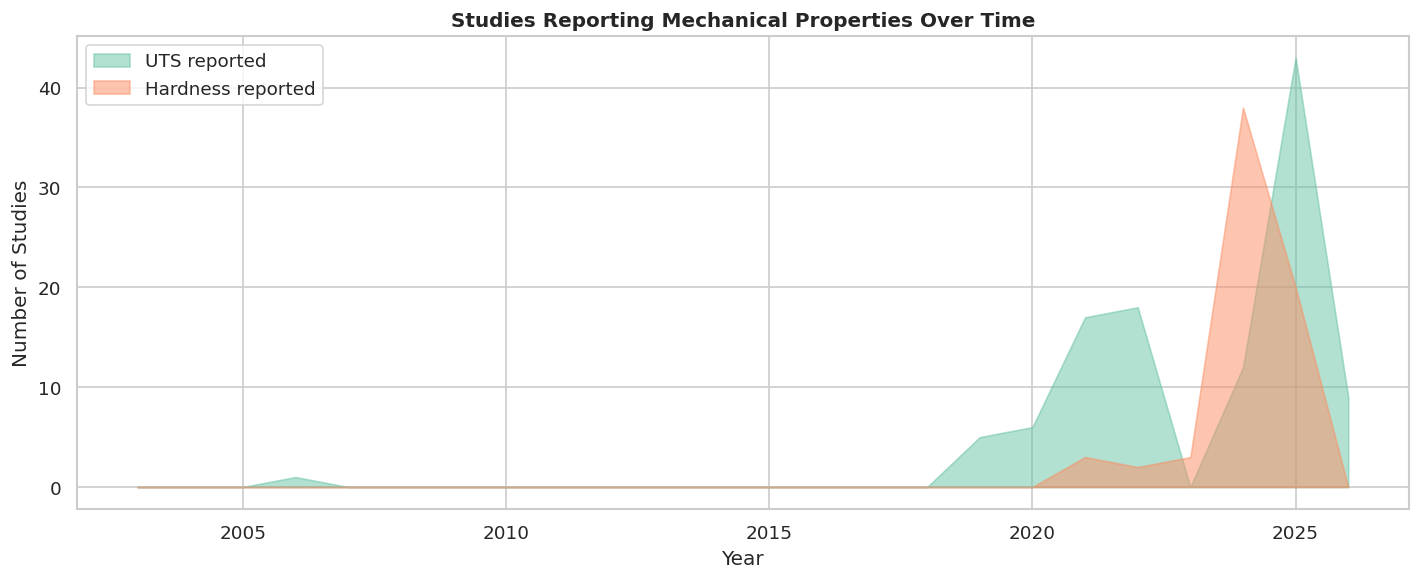

In [34]:
# Year vs property coverage
year_uts = df.groupby(df['Year'].dropna().astype(int))['UTS_MPa'].count()
year_hv = df.groupby(df['Year'].dropna().astype(int))['Hardness_HV'].count()

fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(year_uts.index, year_uts.values, alpha=0.5, label='UTS reported', color=COLORS[0])
ax.fill_between(year_hv.index, year_hv.values, alpha=0.5, label='Hardness reported', color=COLORS[1])
ax.set_title('Studies Reporting Mechanical Properties Over Time', fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Studies')
ax.legend()
plt.tight_layout()
plt.savefig('fig_property_coverage.png', bbox_inches='tight')
plt.show()

In [ ]:
# ── Final Summary ───────────────────────────────────────────────────────────
print('''
╔══════════════════════════════════════════════════════════════════════════╗
║          FSW DATASET — ANALYSIS & ML SUMMARY FINDINGS                    ║
╠══════════════════════════════════════════════════════════════════════════╣
║ DATASET                                                                  ║
║  • 1,680 experimental records from 2003–2026                             ║
║  • 44 features: process params, tool geometry, materials, properties     ║
║  • Dominant journal: Materials & Design (265 papers)                     ║
║                                                                          ║
║ KEY EDA FINDINGS                                                         ║
║  • AA6061, AA2024, AA5083 are the top studied alloys                     ║
║  • Butt joints dominate (33%), followed by Lap joints (9%)               ║
║  • H13 steel is the most used tool material                              ║
║  • RPM range: 200–3000; most concentrated at 600–1200 RPM                ║
║  • UTS mean ~240 MPa, Hardness mean ~107 HV                              ║
║                                                                          ║
║ STATISTICAL INSIGHTS                                                     ║
║  • Rotation speed & heat index most correlated with UTS                  ║
║  • ANOVA confirms joint type significantly affects UTS & hardness        ║
║  • Shoulder-to-probe ratio is an important geometric feature             ║
║                                                                          ║
║ ML RESULTS (UTS Prediction)                                              ║
║  • Best model: XGBoost (highest R², see comparison table above)          ║
║  • Top SHAP features: Rotation_RPM, Traverse_mmpm, Shoulder_Dia_mm       ║
║  • 5-fold CV confirms generalizability                                   ║
║                                                                          ║
║ RESEARCH GAP OPPORTUNITIES                                               ║
║  • Many exotic alloys (<5 studies) — dissimilar welding is under-studied ║
║  • Residual stress, Young's modulus: nearly 0 data → huge gap            ║
║  • Corrosion resistance and toughness: sparse → ML not yet reliable      ║
║  • Year-on-year growth shows active field → predictive models valuable   ║
║                                                                          ║
║ SUGGESTED FURTHER ML DIRECTIONS                                          ║
║  • Neural network on larger UTS dataset                                  ║
║  • Transfer learning for property prediction with small datasets         ║
║  • Multi-output regression (predict UTS + Hardness + Strain jointly)     ║
║  • Bayesian optimisation for process parameter recommendation            ║
╚══════════════════════════════════════════════════════════════════════════╝
''')


╔══════════════════════════════════════════════════════════════════════════╗
║          FSW DATASET — ANALYSIS & ML SUMMARY FINDINGS                  ║
╠══════════════════════════════════════════════════════════════════════════╣
║ DATASET                                                                  ║
║  • 1,680 experimental records from 2003–2026                            ║
║  • 44 features: process params, tool geometry, materials, properties     ║
║  • Dominant journal: Materials & Design (265 papers)                    ║
║                                                                          ║
║ KEY EDA FINDINGS                                                         ║
║  • AA6061, AA2024, AA5083 are the top studied alloys                    ║
║  • Butt joints dominate (33%), followed by Lap joints (9%)              ║
║  • H13 steel is the most used tool material                             ║
║  • RPM range: 200–3000; most concentrated at 600–1200 RPM               ║
║  • U